# 1. Import Libraries, Configuration Setup, and Load the Dataset

## 1.1 Install \& Import Libraries

In [1]:
# !pip install peft==0.13.2, transformers==4.41.1

In [2]:
# !pip install wordcloud

In [3]:
# !pip install imblearn

In [4]:
# !pip install lightgbm

In [5]:
# ── Standard library ─────────────────────────────────────
import os
import re
import gc
import json
import time
import random
import warnings
from pathlib import Path
from itertools import product, combinations
from collections import Counter

# ── Stats ────────────────────────────────────────────────
from statsmodels.stats.contingency_tables import mcnemar
from statsmodels.stats.multitest import multipletests

# ── Core DS stack ────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# ── Scikit-learn ─────────────────────────────────────────
from sklearn.model_selection import GroupShuffleSplit
from sklearn.svm import SVC
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_curve,
    auc,
    accuracy_score,
)
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.utils import resample, shuffle
from sklearn.utils.class_weight import compute_class_weight

# ── Other ML ─────────────────────────────────────────────
from lightgbm import LGBMClassifier
import joblib

# ── NLTK ─────────────────────────────────────────────────
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# ── PyTorch ──────────────────────────────────────────────
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import OneCycleLR
from torch.amp import autocast, GradScaler

# ── Transformers ─────────────────────────────────────────
from transformers import (
    AutoTokenizer,
    AlbertForSequenceClassification,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)

# ── Notebook setup ───────────────────────────────────────
# %matplotlib inline
warnings.filterwarnings("ignore")
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)

True

## 1.2 Seeds \& Device

In [6]:
SEED = 2025

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

USE_FP16 = DEVICE.type == "cuda"
TORCH_COMPILE_OK = hasattr(torch, "compile") and DEVICE.type == "cuda"

Device: cpu


## 1.3 Configuration

In [7]:
DRIVE_PROJECT_PATH = "./01_OriginalLabel"
RAW_DATA_FILE = "data/mental_health_unified_labels_final.csv"
OUTPUT_DIR = "outputs"

TEXT_COLUMN = "statement"
LABEL_COLUMN = "status"
LABEL_COLUMN_ENCODED = "Status_Encoded" # For our new numeric labels

# Explicit ordinal class order (NOT alphabetical)
CLASS_NAMES = ["Anxiety", "Normal", "Depression", "Suicidal", "Stress", "Bipolar", "Personality disorder"]
NUM_CLASSES = len(CLASS_NAMES)

# Training settings
VOCAB_SIZE = 10000
MAX_TOKEN_LENGTH = 200
BATCH_SIZE = 128
N_ITERATIONS = 10
RANDOM_STATE = 42
SEQ_MAX_GRAD_NORM = 5.0
MAX_GRAD_NORM = 1.0

# ── Model file paths ────────────────────────────────────
OUTPUT_PATH = Path(DRIVE_PROJECT_PATH) / OUTPUT_DIR
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

MODEL_PATHS = {
    "lr":      {"model": OUTPUT_PATH / "best_lr_model.joblib",   "params": OUTPUT_PATH / "best_lr_params.json"},
    "svm":     {"model": OUTPUT_PATH / "best_svm_model.joblib",  "params": OUTPUT_PATH / "best_svm_params.json"},
    "rf":      {"model": OUTPUT_PATH / "best_rf_model.joblib",   "params": OUTPUT_PATH / "best_rf_params.json"},
    "lgbm":    {"model": OUTPUT_PATH / "best_lgbm_model.joblib", "params": OUTPUT_PATH / "best_lgbm_params.json"},
    "gru":     {"model": OUTPUT_PATH / "best_gru_model.pth",     "params": OUTPUT_PATH / "best_gru_params.json"},
    "cnn":     {"model": OUTPUT_PATH / "best_cnn_model.pth",     "params": OUTPUT_PATH / "best_cnn_params.json"},
    "albert":  {"model": OUTPUT_PATH / "best_albert_model.pth",  "params": None},
    "biobert": {"model": OUTPUT_PATH / "best_biobert_model.pth", "params": None},
}

RAW_DATA_PATH = os.path.join(DRIVE_PROJECT_PATH, RAW_DATA_FILE)

print("--- Configuration Loaded ---")
print(f"  Project : {DRIVE_PROJECT_PATH}")
print(f"  Classes : {CLASS_NAMES}")
print(f"  FP16    : {USE_FP16}")

--- Configuration Loaded ---
  Project : ./01_OriginalLabel
  Classes : ['Anxiety', 'Normal', 'Depression', 'Suicidal', 'Stress', 'Bipolar', 'Personality disorder']
  FP16    : False


## 1.4 Mount drive \& Load the data

In [8]:
import os
if os.path.ismount("/content/drive"):
    # Already mounted, skip
    pass
else:
    !fusermount -u /content/drive 2>/dev/null
    !rm -rf /content/drive/*
    from google.colab import drive
    drive.mount("/content/drive/", force_remount=True)

df_raw = pd.read_csv(RAW_DATA_PATH, index_col=0)
print(f"Loaded {df_raw.shape[0]} rows.")

df_raw.head()

Mounted at /content/drive/
Loaded 53043 rows.


,statement,status,u_label,u_p_normal,u_p_depression,u_p_anxiety,u_p_suicidal,u_p_stress,u_p_bipolar,u_p_personality_disorder,...,u_model_version,u_system_fingerprint,u_annotation_timestamp,u_raw_json,u_n_conditions,u_any_clinical,u_normal_inferred,u_multilabel,u_max_clinical_prob,u_sum_clinical_prob
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
0,oh my gosh,Anxiety,NORMAL,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,gpt-4o-mini-2024-07-18,fp_373a14eb6f,2026-02-27T18:17:03.262768,"[\n {\n ""index"": 0,\n ""label"": ""NORMAL""...",0,False,True,NORMAL,0.0,0.0
1,"trouble sleeping, confused mind, restless hear...",Anxiety,ANXIETY,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,gpt-4o-mini-2024-07-18,fp_373a14eb6f,2026-02-27T18:17:03.262768,"[\n {\n ""index"": 0,\n ""label"": ""NORMAL""...",1,True,False,ANXIETY,1.0,1.0
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,ANXIETY,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,gpt-4o-mini-2024-07-18,fp_373a14eb6f,2026-02-27T18:17:03.262768,"[\n {\n ""index"": 0,\n ""label"": ""NORMAL""...",1,True,False,ANXIETY,1.0,1.0
3,I've shifted my focus to something else but I'...,Anxiety,ANXIETY,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,gpt-4o-mini-2024-07-18,fp_373a14eb6f,2026-02-27T18:17:03.262768,"[\n {\n ""index"": 0,\n ""label"": ""NORMAL""...",1,True,False,ANXIETY,1.0,1.0
4,"I'm restless and restless, it's been a month n...",Anxiety,ANXIETY,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,gpt-4o-mini-2024-07-18,fp_373a14eb6f,2026-02-27T18:17:03.262768,"[\n {\n ""index"": 0,\n ""label"": ""NORMAL""...",1,True,False,ANXIETY,1.0,1.0


# 2. Data Exploration \& Master Data Preparation

## 2.1 Data Preparation

In [10]:
# Shuffle
df_raw = shuffle(df_raw, random_state=SEED).reset_index(drop=True)
df_raw

,statement,status,u_label,u_p_normal,u_p_depression,u_p_anxiety,u_p_suicidal,u_p_stress,u_p_bipolar,u_p_personality_disorder,...,u_model_version,u_system_fingerprint,u_annotation_timestamp,u_raw_json,u_n_conditions,u_any_clinical,u_normal_inferred,u_multilabel,u_max_clinical_prob,u_sum_clinical_prob
0,My whole life has been meaningless. Everyday I...,Depression,DEPRESSION,0.0,0.5,0.0,0.1,0.4,0.0,0.0,...,gpt-4o-mini-2024-07-18,fp_373a14eb6f,2026-02-27T19:28:18.559023,"[\n {\n ""index"": 0,\n ""label""...",2,True,False,DEPRESSION+STRESS,0.5,1.0
1,my bf of 7 months broke up with me simply beca...,Suicidal,SUICIDAL,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,gpt-4o-mini-2024-07-18,fp_373a14eb6f,2026-02-27T21:25:11.615707,"[\n {\n ""index"": 0,\n ""label""...",2,True,False,DEPRESSION+SUICIDAL,1.0,1.0
2,is that right?,Normal,NORMAL,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,gpt-4o-mini-2024-07-18,fp_373a14eb6f,2026-02-27T21:49:02.356838,"[\n {\n ""index"": 0,\n ""label"": ""NORMAL""...",0,False,True,NORMAL,0.0,0.0
3,"Panic, pain and tingling in limbs - is my birt...",Anxiety,ANXIETY,0.0,0.1,0.9,0.0,0.0,0.0,0.0,...,gpt-4o-mini-2024-07-18,fp_373a14eb6f,2026-02-27T22:16:19.123169,"[\n {\n ""index"": 0,\n ""label""...",1,True,False,ANXIETY,0.9,1.0
4,I sleep every night wishing I could never wake...,Depression,SUICIDAL,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,gpt-4o-mini-2024-07-18,fp_373a14eb6f,2026-02-27T19:43:43.691903,"[\n {\n ""index"": 0,\n ""label""...",2,True,False,DEPRESSION+SUICIDAL,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53038,Ever wake up in the morning with a strange pai...,Depression,NORMAL,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,gpt-4o-mini-2024-07-18,fp_373a14eb6f,2026-02-27T20:12:38.675706,"[\n {\n ""index"": 0,\n ""label""...",0,False,True,NORMAL,0.0,0.0
53039,I often find myself wishing they were If guns ...,Depression,SUICIDAL,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,gpt-4o-mini-2024-07-18,fp_373a14eb6f,2026-02-27T19:33:12.331697,"[\n {\n ""index"": 0,\n ""label""...",1,True,False,SUICIDAL,1.0,1.0
53040,"I thought I had some really close friends, but...",Depression,DEPRESSION,0.0,0.8,0.0,0.0,0.2,0.0,0.0,...,gpt-4o-mini-2024-07-18,fp_373a14eb6f,2026-02-27T20:16:44.055325,"[\n {\n ""index"": 0,\n ""label""...",1,True,False,DEPRESSION,0.8,1.0
53041,that's dangerous.,Normal,NORMAL,0.8,0.0,0.0,0.0,0.0,0.0,0.0,...,gpt-4o-mini-2024-07-18,fp_373a14eb6f,2026-02-27T21:59:35.430030,"[\n {\n ""index"": 0,\n ""label"": ""NORMAL""...",0,False,True,NORMAL,0.0,0.0


## 2.2 Master Data Preparation

In [11]:
def clean_text(text: str) -> str:
    if pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+", " urltoken ", text)
    text = re.sub(r"@\w+", " usertoken ", text)
    text = re.sub(r"#(\w+)", r" hashtag_\1 ", text)
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


print("Cleaning text...")
df_clean = df_raw.copy()
df_clean[TEXT_COLUMN] = df_clean[TEXT_COLUMN].apply(clean_text)

Cleaning text...


In [12]:
label_encoder = LabelEncoder()
label_encoder.classes_ = np.array(CLASS_NAMES)  # force ordinal order
df_clean[LABEL_COLUMN_ENCODED] = label_encoder.transform(df_clean[LABEL_COLUMN])

print(f"Label mapping: {dict(zip(CLASS_NAMES, range(NUM_CLASSES)))}")
print(f"df_clean: {df_clean.shape[0]} rows")


Label mapping: {'Anxiety': 0, 'Normal': 1, 'Depression': 2, 'Suicidal': 3, 'Stress': 4, 'Bipolar': 5, 'Personality disorder': 6}
df_clean: 53043 rows


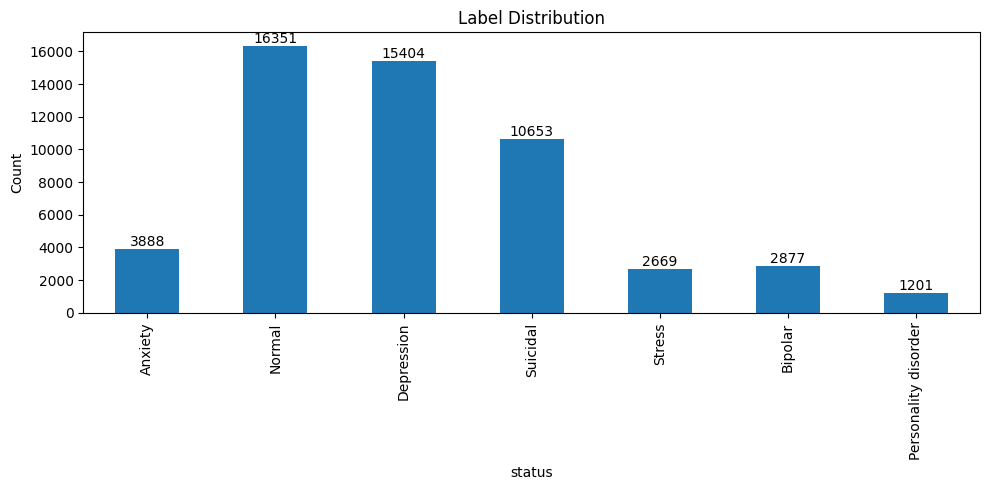

In [ ]:
plt.figure(figsize=(10, 5))
counts = df_clean[LABEL_COLUMN].value_counts().reindex(CLASS_NAMES)
ax = counts.plot(kind="bar")
for i, v in enumerate(counts):
    ax.text(i, v, str(v), ha="center", va="bottom")
plt.title("Label Distribution")
plt.xlabel(LABEL_COLUMN)
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## 2.3 Master Data Split

In [ ]:
groups = df_clean[TEXT_COLUMN]
y = df_clean[LABEL_COLUMN_ENCODED]

# 80/20 → trainval / test
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
trainval_idx, test_idx = next(gss_test.split(df_clean, y, groups=groups))

split = np.full(len(df_clean), "train", dtype=object)
split[test_idx] = "test"

# 75/25 of trainval → train / val (≈60/20/20)
df_trainval = df_clean.iloc[trainval_idx].copy().reset_index(drop=True)
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
train_idx2, val_idx = next(
    gss_val.split(df_trainval, df_trainval[LABEL_COLUMN_ENCODED], groups=df_trainval[TEXT_COLUMN])
)
split[trainval_idx[val_idx]] = "val"
df_clean["split"] = split

print("Split counts:")
print(df_clean["split"].value_counts())

# Leakage check
n_leaky = (df_clean.groupby(TEXT_COLUMN)["split"].nunique() > 1).sum()
assert n_leaky == 0, f"{n_leaky} text groups leak across splits!"
print(f"Leakage check passed.")

print("Split proportions:")
print(df_clean["split"].value_counts(normalize=True))

# Save master split
split_path = OUTPUT_PATH / "MentalHealth_master_split.csv"
df_clean.to_csv(split_path, index=False)
print(f"Saved → {split_path}")

Split counts:
split
train    31976
test     10550
val      10517
Name: count, dtype: int64
Leakage check passed.
Split proportions:
split
train    0.602832
test     0.198895
val      0.198273
Name: proportion, dtype: float64
Saved → ./01_OriginalLabel/outputs/MentalHealth_master_split.csv


## 2.4 Shared helper functions

### 2.4.1 Bootstrap CI

In [ ]:
def bootstrap_f1_ci(y_true, y_pred, n_iterations=1000, average="weighted"):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    scores = []
    for _ in range(n_iterations):
        idx = resample(np.arange(len(y_true)))
        try:
            scores.append(f1_score(y_true[idx], y_pred[idx], average=average))
        except ValueError:
            continue
    if not scores:
        return np.nan, np.nan, np.nan
    return np.mean(scores), np.percentile(scores, 2.5), np.percentile(scores, 97.5)


def bootstrap_auc_ci(y_true, y_scores, n_iterations=1000, average="macro"):
    y_true, y_scores = np.asarray(y_true), np.asarray(y_scores)
    scores = []
    for _ in range(n_iterations):
        idx = resample(np.arange(len(y_true)))
        try:
            scores.append(
                roc_auc_score(y_true[idx], y_scores[idx], average=average, multi_class="ovr")
            )
        except ValueError:
            continue
    if not scores:
        return np.nan, np.nan, np.nan
    return np.mean(scores), np.percentile(scores, 2.5), np.percentile(scores, 97.5)

### 2.4.2 Plotting

In [ ]:
def plot_confusion_matrix(y_true, y_pred, labels, title="Model", save_dir=None):
    """Works for both string labels (ML) and int labels (DL)."""
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix — {title}")
    plt.tight_layout()
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        path = os.path.join(save_dir, f"{title}_confusion_matrix.png")
        plt.savefig(path, dpi=300)
        print(f"Saved → {path}")
    plt.show()


def plot_multiclass_roc(y_true, y_score, classes_list, title="Model", save_dir=None):
    """Works for both string and int class lists."""
    y_true_bin = label_binarize(y_true, classes=classes_list)
    n_classes = len(classes_list)
    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    colors = sns.color_palette("mako", n_classes)
    plt.figure(figsize=(10, 8))
    for i, (cls, color) in enumerate(zip(classes_list, colors)):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f"{cls} (AUC={roc_auc[i]:.2f})")
    plt.plot([0, 1], [0, 1], "k--", lw=2)
    plt.xlim([0, 1])
    plt.ylim([0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{title} — Multi-class ROC")
    plt.legend(loc="lower right")
    plt.tight_layout()
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        path = os.path.join(save_dir, f"{title}_roc_curve.png")
        plt.savefig(path, dpi=300)
        print(f"Saved → {path}")
    plt.show()

### 2.4.3 Machine Learning Evaluation Wrapper

In [ ]:
def evaluate_ml(model, X_test, y_test, model_name="Model"):
    """Full evaluation for a fitted sklearn classifier."""
    print(f"\n{'='*50}")
    print(f"Evaluation: {model_name}")
    print(f"{'='*50}")

    y_pred = model.predict(X_test)
    classes = model.classes_

    print(classification_report(y_test, y_pred, digits=4, labels=classes))

    f1_m, f1_lo, f1_hi = bootstrap_f1_ci(y_test, y_pred)
    print(f"Weighted F1: {f1_m:.4f}  95% CI [{f1_lo:.4f}, {f1_hi:.4f}]")

    plot_confusion_matrix(y_test, y_pred, labels=classes,
                         title=model_name, save_dir=str(OUTPUT_PATH))

    if hasattr(model, "predict_proba"):
        y_scores = model.predict_proba(X_test)
    elif hasattr(model, "decision_function"):
        y_scores = model.decision_function(X_test)
    else:
        print("No probability scores available.")
        return

    auc_m, auc_lo, auc_hi = bootstrap_auc_ci(y_test, y_scores)
    print(f"Macro AUC: {auc_m:.4f}  95% CI [{auc_lo:.4f}, {auc_hi:.4f}]")

    plot_multiclass_roc(y_test, y_scores, classes,
                       title=model_name, save_dir=str(OUTPUT_PATH))

### 2.4.4 PyTorch Evaluation Wrapper

In [ ]:
@torch.no_grad()
def evaluate_pytorch(model, test_loader, label_encoder, model_name="Model",
                     use_attention_mask=True):
    """Full evaluation for a PyTorch classifier."""
    model.eval().to(DEVICE)
    all_preds, all_probs, all_labels = [], [], []

    for batch in tqdm(test_loader, desc=f"Eval {model_name}"):
        ids = batch["input_ids"].to(DEVICE, non_blocking=True)
        labels = batch["label"].to(DEVICE, non_blocking=True)

        if use_attention_mask:
            mask = batch["attention_mask"].to(DEVICE, non_blocking=True)
            with autocast("cuda", enabled=USE_FP16):
                outputs = model(input_ids=ids, attention_mask=mask)
        else:
            with autocast("cuda", enabled=USE_FP16):
                outputs = model(input_ids=ids)

        logits = outputs.logits if hasattr(outputs, "logits") else outputs
        probs = torch.softmax(logits.float(), dim=1)
        preds = probs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    classes_str = label_encoder.classes_
    classes_int = np.arange(NUM_CLASSES)

    print(f"\n{'='*50}")
    print(f"Evaluation: {model_name}")
    print(f"{'='*50}")

    print(classification_report(all_labels, all_preds,
                                target_names=classes_str, digits=4))

    f1_m, f1_lo, f1_hi = bootstrap_f1_ci(all_labels, all_preds)
    print(f"Weighted F1: {f1_m:.4f}  95% CI [{f1_lo:.4f}, {f1_hi:.4f}]")

    plot_confusion_matrix(all_labels, all_preds, labels=classes_int,
                         title=model_name, save_dir=str(OUTPUT_PATH))

    auc_m, auc_lo, auc_hi = bootstrap_auc_ci(all_labels, all_probs)
    print(f"Macro AUC: {auc_m:.4f}  95% CI [{auc_lo:.4f}, {auc_hi:.4f}]")

    plot_multiclass_roc(all_labels, all_probs, classes_int,
                       title=model_name, save_dir=str(OUTPUT_PATH))

    return all_preds, all_probs, all_labels

### 2.4.5 Machine Learning Feature Importance (shared)

In [ ]:
def plot_feature_importance(importances, feature_names, model_name="Model", top_n=20):
    """Generic feature importance plot for any ML model."""
    df_imp = pd.DataFrame({"Feature": feature_names, "Importance": importances})
    df_imp["Scaled"] = (df_imp["Importance"] / df_imp["Importance"].max()) * 100
    top = df_imp.sort_values("Importance", ascending=False).head(top_n)

    plt.figure(figsize=(8, 6))
    sns.set_style("whitegrid")
    sns.barplot(x="Scaled", y="Feature", data=top[::-1], palette="mako")
    plt.title(f"Top {top_n} Feature Importance ({model_name})", fontsize=14, fontweight="bold")
    plt.xlabel("Relative Importance (%)")
    plt.ylabel("Feature")
    plt.tight_layout()

    path = OUTPUT_PATH / f"{model_name.lower().replace(' ', '_')}_feature_importance.png"
    plt.savefig(path, dpi=300)
    print(f"Saved → {path}")
    plt.show()

    return top

# 3. Classical ML Modeling

## 3.0 Pre-processing for classical ML Models


In [ ]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


def ml_preprocess(text: str) -> str:
    if not isinstance(text, str):
        return ""
    tokens = [lemmatizer.lemmatize(w) for w in text.split() if w not in stop_words]
    return " ".join(tokens)


df_ml = df_clean.copy()
df_ml["text_ml"] = df_ml[TEXT_COLUMN].apply(ml_preprocess)

df_train_ml = df_ml[df_ml["split"] == "train"].copy()
df_val_ml   = df_ml[df_ml["split"] == "val"].copy()
df_test_ml  = df_ml[df_ml["split"] == "test"].copy()

X_train_ml = df_train_ml["text_ml"].tolist()
X_val_ml   = df_val_ml["text_ml"].tolist()
X_test_ml  = df_test_ml["text_ml"].tolist()

y_train_ml = df_train_ml[LABEL_COLUMN].astype(str).values
y_val_ml   = df_val_ml[LABEL_COLUMN].astype(str).values
y_test_ml  = df_test_ml[LABEL_COLUMN].astype(str).values

# TF-IDF (no stop_words param — already removed in ml_preprocess)
tfidf = TfidfVectorizer(max_features=VOCAB_SIZE)
X_train_tfidf = tfidf.fit_transform(X_train_ml)
X_val_tfidf   = tfidf.transform(X_val_ml)
X_test_tfidf  = tfidf.transform(X_test_ml)

print(f"TF-IDF: train={X_train_tfidf.shape}, val={X_val_tfidf.shape}, test={X_test_tfidf.shape}")
feature_names_tfidf = tfidf.get_feature_names_out()

print(f"ML splits: train={len(df_train_ml)}, val={len(df_val_ml)}, test={len(df_test_ml)}")

TF-IDF: train=(31976, 10000), val=(10517, 10000), test=(10550, 10000)
ML splits: train=31976, val=10517, test=10550


## 3.1 Logistic Regression

### Step 1: Hyperparameter Tuning

In [ ]:
RETRAIN = True
if RETRAIN:
    # 7.1 Hyperparameter Tuning (grid search)
    set_seed()
    print("Tuning Logistic Regression...")
    start = time.time()

    lr_grid = {
        "C": [0.1, 1, 10],
        "solver": ["lbfgs", "saga"],
        "class_weight": ["balanced", None],
    }

    best_f1_lr, best_model_lr, best_params_lr = 0, None, None

    for C, solver, cw in product(lr_grid["C"], lr_grid["solver"], lr_grid["class_weight"]):
        try:
            model = LogisticRegression(
                C=C, solver=solver, penalty="l2", multi_class="multinomial",
                class_weight=cw, max_iter=1000, random_state=RANDOM_STATE,
                n_jobs=-1 if solver == "saga" else None,
            )
            model.fit(X_train_tfidf, y_train_ml)
            f1 = f1_score(y_val_ml, model.predict(X_val_tfidf), average="weighted")
            if f1 > best_f1_lr:
                best_f1_lr = f1
                best_model_lr = model
                best_params_lr = {"C": C, "solver": solver, "class_weight": cw}
                print(f"  LR F1={f1:.4f} | {best_params_lr}")
        except Exception as e:
            print(f"  Skipped: {e}")

    print(f"LR tuning: {time.time()-start:.1f}s | Best F1={best_f1_lr:.4f}")

    joblib.dump(best_model_lr, MODEL_PATHS["lr"]["model"])
    with open(MODEL_PATHS["lr"]["params"], "w") as f:
        json.dump(best_params_lr, f, indent=2)
else:
    print("Loading LR from disk...")
    best_model_lr = joblib.load(MODEL_PATHS["lr"]["model"])
    print(f"Loaded LR from {MODEL_PATHS['lr']['model']}")

Tuning Logistic Regression...
  LR F1=0.7135 | {'C': 0.1, 'solver': 'lbfgs', 'class_weight': 'balanced'}
  LR F1=0.7135 | {'C': 0.1, 'solver': 'saga', 'class_weight': 'balanced'}
  LR F1=0.7336 | {'C': 1, 'solver': 'lbfgs', 'class_weight': 'balanced'}
  LR F1=0.7419 | {'C': 1, 'solver': 'lbfgs', 'class_weight': None}
  LR F1=0.7425 | {'C': 1, 'solver': 'saga', 'class_weight': None}
LR tuning: 214.2s | Best F1=0.7425


### Step 2: Model Evaluation


Evaluation: Logistic_Regression
                      precision    recall  f1-score   support

             Anxiety     0.7966    0.7258    0.7596       766
             Bipolar     0.8702    0.6476    0.7426       559
          Depression     0.7026    0.7419    0.7217      3092
              Normal     0.8352    0.9515    0.8895      3275
Personality disorder     0.7840    0.4495    0.5714       218
              Stress     0.6762    0.4226    0.5201       504
            Suicidal     0.6845    0.6409    0.6620      2136

            accuracy                         0.7591     10550
           macro avg     0.7642    0.6543    0.6953     10550
        weighted avg     0.7562    0.7591    0.7528     10550

Weighted F1: 0.7529  95% CI [0.7437, 0.7618]
Saved → ./01_OriginalLabel/outputs/Logistic_Regression_confusion_matrix.png


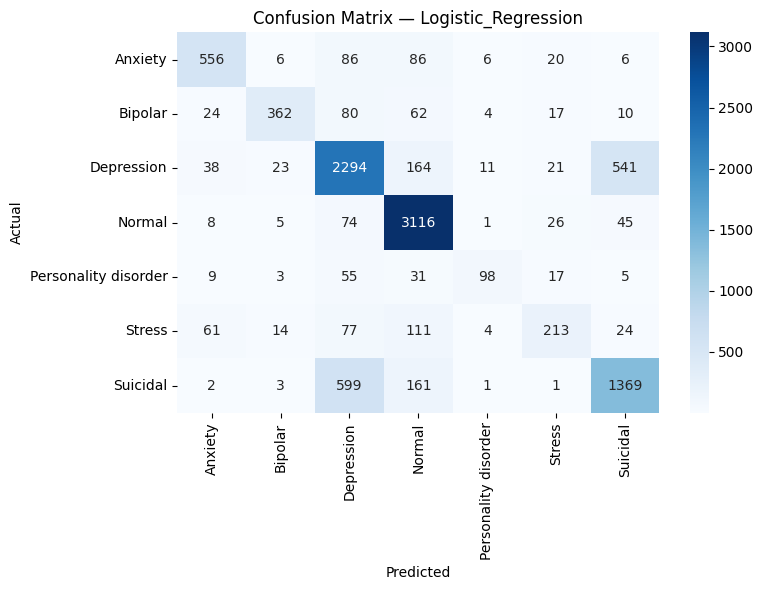

Macro AUC: 0.9542  95% CI [0.9515, 0.9570]
Saved → ./01_OriginalLabel/outputs/Logistic_Regression_roc_curve.png


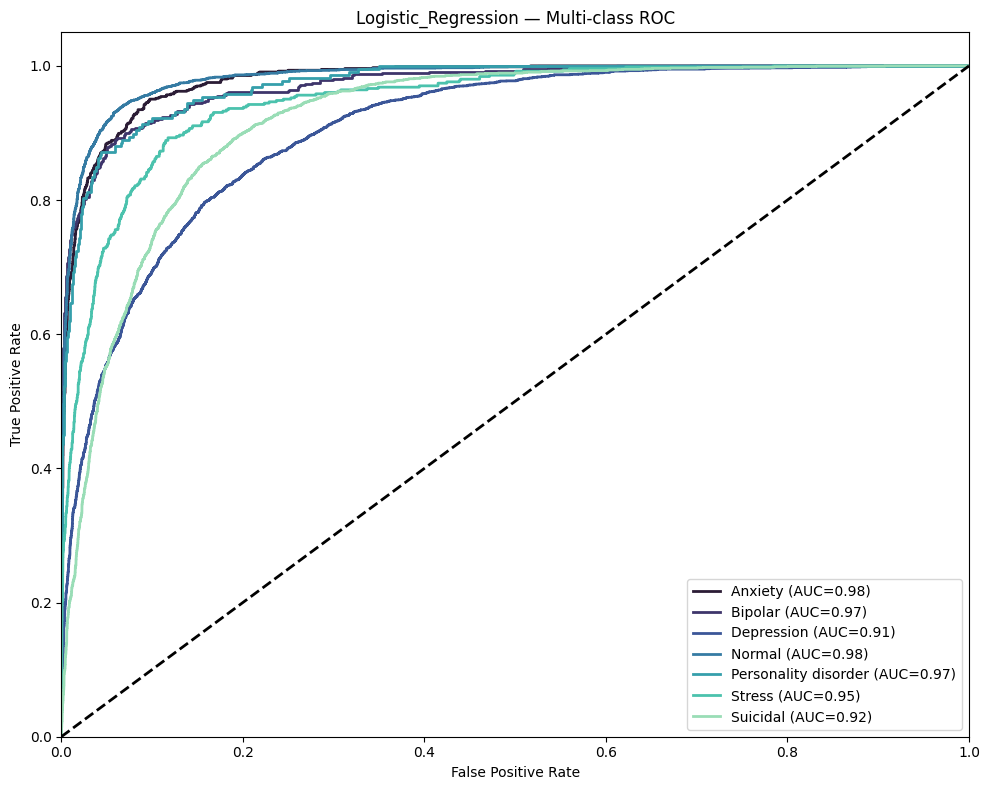

In [ ]:
evaluate_ml(best_model_lr, X_test_tfidf, y_test_ml, "Logistic_Regression")

### Step 3: Model Interpretation

Saved → ./01_OriginalLabel/outputs/logistic_regression_feature_importance.png


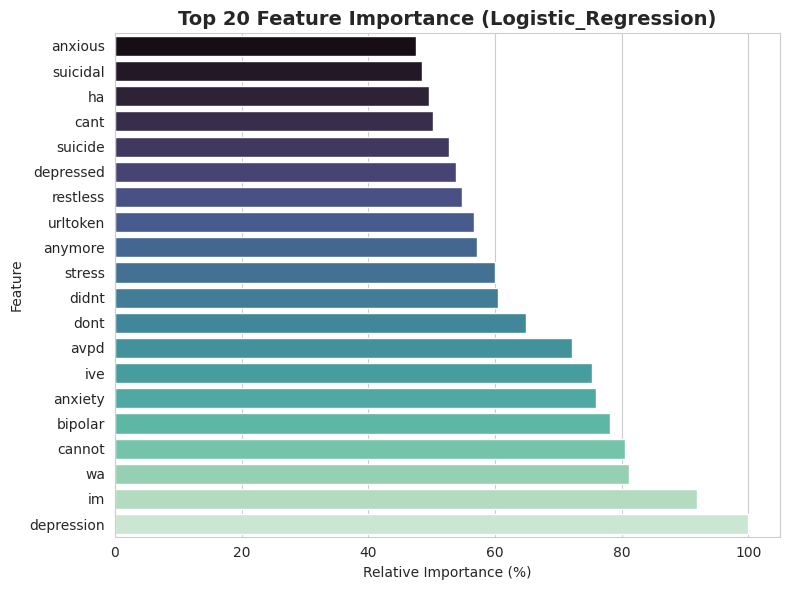

In [ ]:
if hasattr(best_model_lr, "coef_"):
    importances_lr = np.abs(best_model_lr.coef_).mean(axis=0) if best_model_lr.coef_.shape[0] > 1 else np.abs(best_model_lr.coef_[0])
    plot_feature_importance(importances_lr, feature_names_tfidf, "Logistic_Regression")

## 3.2 SVM

### Step 1: Hyperparameter Tuning

In [ ]:
### Step 1: Hyperparameter Tuning

RETRAIN = True
if RETRAIN:
    set_seed()
    print("\nTuning SVM...")
    start = time.time()

    svm_grid = {
        "C": [0.1, 1, 10],
        "kernel": ["linear", "rbf"],
        "class_weight": ["balanced", None],
        "gamma": ["scale"],
    }

    best_f1_svm, best_params_svm, best_model_svm = 0, None, None

    for C, kernel, class_weight, gamma in product(
        svm_grid["C"], svm_grid["kernel"],
        svm_grid["class_weight"], svm_grid["gamma"]
    ):
        try:
            model = SVC(
                C=C, kernel=kernel, class_weight=class_weight,
                gamma=gamma, random_state=RANDOM_STATE, probability=False,
            )
            model.fit(X_train_tfidf, y_train_ml)
            y_val_pred = model.predict(X_val_tfidf)
            f1 = f1_score(y_val_ml, y_val_pred, average="weighted")

            if f1 > best_f1_svm:
                best_f1_svm = f1
                best_params_svm = {"C": C, "kernel": kernel,
                                   "class_weight": class_weight, "gamma": gamma}
                best_model_svm = model
                print(f"  New best F1: {f1:.4f} | {best_params_svm}")

        except Exception as e:
            print(f"  Skipping: {e}")

    # Retrain best config with probability=True for predict_proba
    print("\nRetraining best SVM with probability=True...")
    best_model_svm = SVC(
        **best_params_svm,
        random_state=RANDOM_STATE, probability=True,
    )
    best_model_svm.fit(X_train_tfidf, y_train_ml)

    elapsed = time.time() - start
    print(f"\nBest SVM: F1={best_f1_svm:.4f} in {elapsed:.1f}s")
    print(f"Params: {best_params_svm}")

    joblib.dump(best_model_svm, MODEL_PATHS["svm"]["model"])
    with open(MODEL_PATHS["svm"]["params"], "w") as f:
        json.dump(best_params_svm, f, indent=2)
    print(f"Saved best SVM model to: {MODEL_PATHS['svm']['model']}")
else:
    best_model_svm = joblib.load(MODEL_PATHS["svm"]["model"])
    with open(MODEL_PATHS["svm"]["params"]) as f:
        best_params_svm = json.load(f)
    print(f"Loaded saved SVM model. Params: {best_params_svm}")


Tuning SVM...
  New best F1: 0.7195 | {'C': 0.1, 'kernel': 'linear', 'class_weight': 'balanced', 'gamma': 'scale'}
  New best F1: 0.7409 | {'C': 1, 'kernel': 'linear', 'class_weight': 'balanced', 'gamma': 'scale'}
  New best F1: 0.7489 | {'C': 1, 'kernel': 'linear', 'class_weight': None, 'gamma': 'scale'}

Retraining best SVM with probability=True...

Best SVM: F1=0.7489 in 6058.2s
Params: {'C': 1, 'kernel': 'linear', 'class_weight': None, 'gamma': 'scale'}
Saved best SVM model to: ./01_OriginalLabel/outputs/best_svm_model.joblib


### Step 2: Model Evaluation


Evaluation: SVM
                      precision    recall  f1-score   support

             Anxiety     0.7728    0.7637    0.7682       766
             Bipolar     0.8545    0.6726    0.7528       559
          Depression     0.6956    0.7345    0.7145      3092
              Normal     0.8634    0.9456    0.9027      3275
Personality disorder     0.8145    0.4633    0.5906       218
              Stress     0.6354    0.4563    0.5312       504
            Suicidal     0.6814    0.6428    0.6615      2136

            accuracy                         0.7614     10550
           macro avg     0.7597    0.6684    0.7031     10550
        weighted avg     0.7584    0.7614    0.7568     10550

Weighted F1: 0.7569  95% CI [0.7485, 0.7655]
Saved → ./01_OriginalLabel/outputs/SVM_confusion_matrix.png


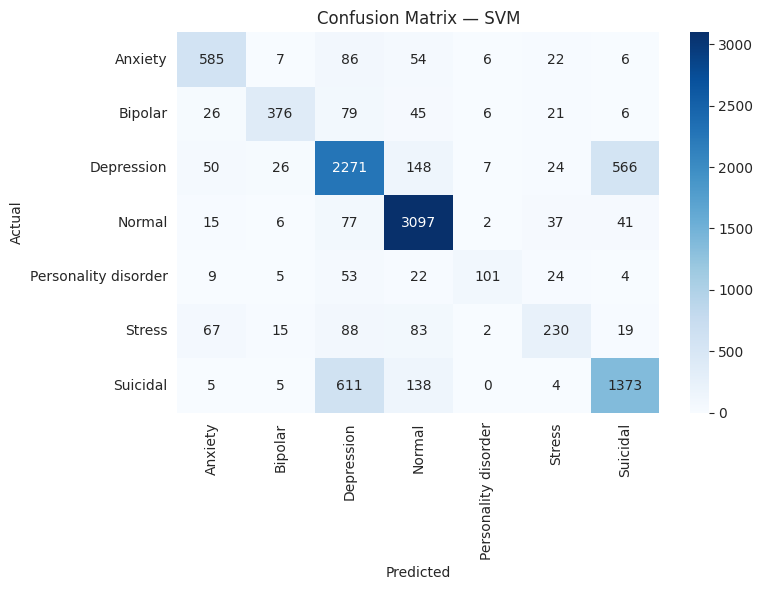

Macro AUC: 0.9533  95% CI [0.9503, 0.9564]
Saved → ./01_OriginalLabel/outputs/SVM_roc_curve.png


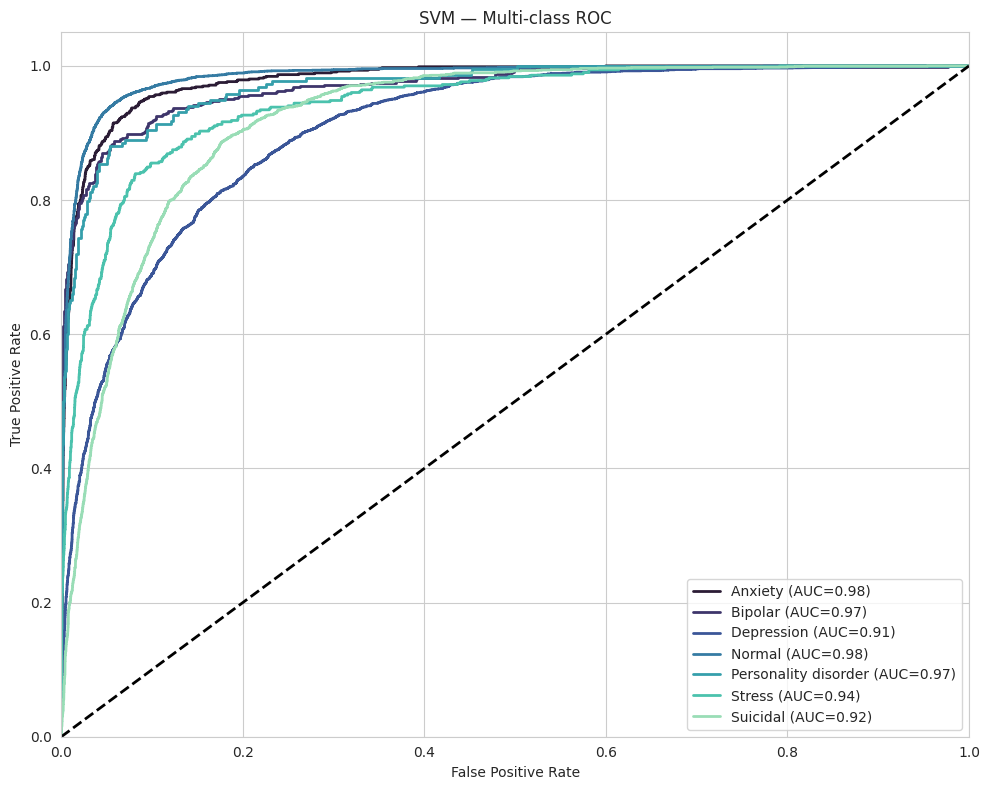

In [ ]:
evaluate_ml(best_model_svm, X_test_tfidf, y_test_ml, "SVM")

### Step 3: Model Interpretation

In [ ]:
# if best_model_svm.kernel == "linear" and hasattr(best_model_svm, "coef_"):
#     # Linear kernel: use coefficient weights directly (fast)
#     importances_svm = np.abs(best_model_svm.coef_).mean(axis=0)
#     if hasattr(importances_svm, "A1"):  # sparse matrix → flat array
#         importances_svm = importances_svm.A1
#     plot_feature_importance(importances_svm, feature_names_tfidf, "SVM")
# else:
#     # Non-linear kernel: permutation importance (slower)
#     print(f"Kernel='{best_model_svm.kernel}' — using permutation importance...")

#     max_samples = 1000
#     n_val = X_val_tfidf.shape[0]

#     if n_val > max_samples:
#         rng = np.random.RandomState(RANDOM_STATE)
#         idx = rng.choice(n_val, size=max_samples, replace=False)
#         X_perm = X_val_tfidf[idx]
#         y_perm = y_val_ml.iloc[idx] if hasattr(y_val_ml, "iloc") else y_val_ml[idx]
#     else:
#         X_perm = X_val_tfidf
#         y_perm = y_val_ml

#     print(f"Permutation importance on {X_perm.shape[0]} samples...")
#     start = time.time()

#     result = permutation_importance(
#         best_model_svm, X_perm, y_perm,
#         n_repeats=5, random_state=RANDOM_STATE,
#         n_jobs=-1, scoring="f1_weighted",
#     )

#     print(f"Done in {time.time() - start:.1f}s")

#     importances_svm = result.importances_mean.clip(min=0)
#     plot_feature_importance(importances_svm, feature_names_tfidf, "SVM")

## 3.3 Random Forest

### Step 1: Hyperparameter Tuning

In [ ]:
RETRAIN = True
if RETRAIN:
    set_seed()
    print("\nTuning Random Forest...")
    start = time.time()

    rf_grid = {
        "n_estimators": [50, 100, 200],
        "max_depth": [None, 10, 20],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "class_weight": ["balanced", None],
    }

    best_f1_rf, best_model_rf, best_params_rf = 0, None, None

    for n_est, md, mss, msl, cw in tqdm(
        list(product(rf_grid["n_estimators"], rf_grid["max_depth"],
                     rf_grid["min_samples_split"], rf_grid["min_samples_leaf"],
                     rf_grid["class_weight"])),
        desc="RF grid"
    ):
        try:
            model = RandomForestClassifier(
                n_estimators=n_est, max_depth=md, min_samples_split=mss,
                min_samples_leaf=msl, class_weight=cw,
                random_state=RANDOM_STATE, n_jobs=-1,
            )
            model.fit(X_train_tfidf, y_train_ml)
            f1 = f1_score(y_val_ml, model.predict(X_val_tfidf), average="weighted")
            if f1 > best_f1_rf:
                best_f1_rf = f1
                best_model_rf = model
                best_params_rf = {"n_estimators": n_est, "max_depth": md,
                                  "min_samples_split": mss, "min_samples_leaf": msl,
                                  "class_weight": cw}
        except Exception as e:
            print(f"  Skipped: {e}")

    print(f"RF tuning: {time.time()-start:.1f}s | Best F1={best_f1_rf:.4f}")
    print(f"Best params: {best_params_rf}")

    joblib.dump(best_model_rf, MODEL_PATHS["rf"]["model"])
    with open(MODEL_PATHS["rf"]["params"], "w") as f:
        json.dump(best_params_rf, f, indent=2)
else:
    print("Loading RF from disk...")
    best_model_rf = joblib.load(MODEL_PATHS["rf"]["model"])
    print(f"Loaded RF from {MODEL_PATHS['rf']['model']}")


Tuning Random Forest...


RF grid: 100%|██████████| 162/162 [09:27<00:00,  3.50s/it]


RF tuning: 567.7s | Best F1=0.7292
Best params: {'n_estimators': 200, 'max_depth': None, 'min_samples_split': 10, 'min_samples_leaf': 4, 'class_weight': 'balanced'}


### Step 2: Model Evaluation


Evaluation: RandomForest
                      precision    recall  f1-score   support

             Anxiety     0.6976    0.8251    0.7560       766
             Bipolar     0.7213    0.7406    0.7308       559
          Depression     0.7663    0.6151    0.6825      3092
              Normal     0.8732    0.9148    0.8935      3275
Personality disorder     0.7532    0.5459    0.6330       218
              Stress     0.4982    0.5536    0.5244       504
            Suicidal     0.6228    0.7111    0.6640      2136

            accuracy                         0.7451     10550
           macro avg     0.7046    0.7009    0.6977     10550
        weighted avg     0.7500    0.7451    0.7436     10550

Weighted F1: 0.7435  95% CI [0.7354, 0.7522]
Saved → ./01_OriginalLabel/outputs/RandomForest_confusion_matrix.png


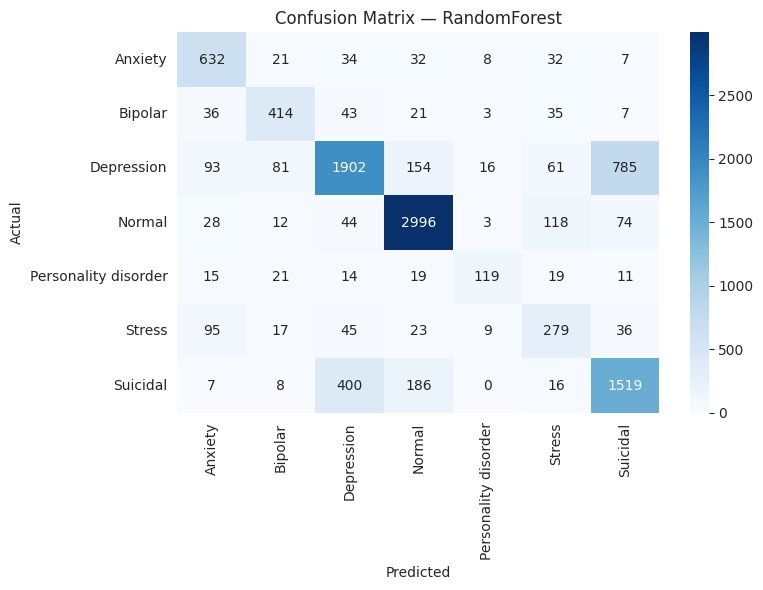

Macro AUC: 0.9335  95% CI [0.9298, 0.9373]
Saved → ./01_OriginalLabel/outputs/RandomForest_roc_curve.png


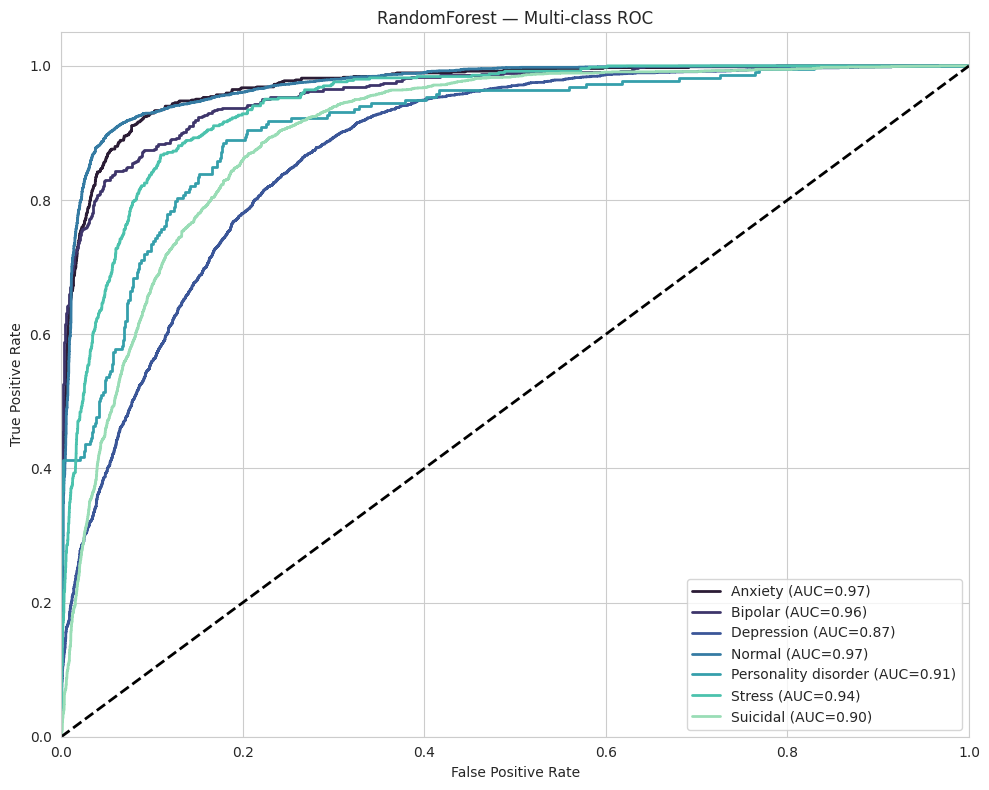

In [ ]:
evaluate_ml(best_model_rf, X_test_tfidf, y_test_ml, "RandomForest")

### Step 3: Model Interpretation

Saved → ./01_OriginalLabel/outputs/randomforest_feature_importance.png


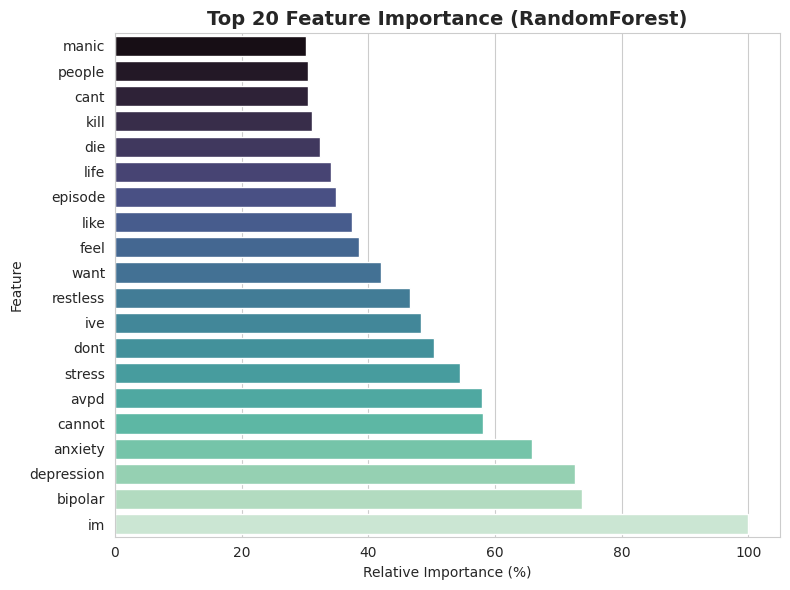

,Feature,Importance,Scaled
4512,im,0.027837,100.000000
1120,bipolar,0.020506,73.665295
2451,depression,0.020232,72.679302
630,anxiety,0.018308,65.769288
1455,cannot,0.016157,58.041543
876,avpd,0.016154,58.032578
8491,stress,0.015168,54.488325
2765,dont,0.014014,50.342252
4887,ive,0.013441,48.285535
7426,restless,0.012963,46.568769


In [ ]:
plot_feature_importance(best_model_rf.feature_importances_, feature_names_tfidf, "RandomForest")

## 3.4 LGBM

### Step 1: Hyperparameter Tuning

In [ ]:
RETRAIN = True
if RETRAIN:
    set_seed()
    print("\nTuning LightGBM...")
    start = time.time()

    lgbm_grid = {
        "n_estimators": [100, 200],
        "learning_rate": [0.01, 0.1, 0.2],
        "num_leaves": [31, 63],
        "max_depth": [None, 10],
        "class_weight": ["balanced", None],
    }

    best_f1_lgbm, best_model_lgbm, best_params_lgbm = 0, None, None

    for n_est, lr, nl, md, cw in tqdm(
        list(product(lgbm_grid["n_estimators"], lgbm_grid["learning_rate"],
                     lgbm_grid["num_leaves"], lgbm_grid["max_depth"],
                     lgbm_grid["class_weight"])),
        desc="LGBM grid"
    ):
        try:
            model = LGBMClassifier(
                objective="multiclass", n_estimators=n_est, learning_rate=lr,
                num_leaves=nl, max_depth=-1 if md is None else md,
                class_weight=cw, random_state=RANDOM_STATE, n_jobs=-1,
                verbose=-1,
            )
            model.fit(X_train_tfidf, y_train_ml)
            f1 = f1_score(y_val_ml, model.predict(X_val_tfidf), average="weighted")
            if f1 > best_f1_lgbm:
                best_f1_lgbm = f1
                best_model_lgbm = model
                best_params_lgbm = {"n_estimators": n_est, "learning_rate": lr,
                                    "num_leaves": nl, "max_depth": md, "class_weight": cw}
        except Exception as e:
            print(f"  Skipped: {e}")

    print(f"LGBM tuning: {time.time()-start:.1f}s | Best F1={best_f1_lgbm:.4f}")
    print(f"Best params: {best_params_lgbm}")

    joblib.dump(best_model_lgbm, MODEL_PATHS["lgbm"]["model"])
    with open(MODEL_PATHS["lgbm"]["params"], "w") as f:
        json.dump(best_params_lgbm, f, indent=2)
else:
    print("Loading LGBM from disk...")
    best_model_lgbm = joblib.load(MODEL_PATHS["lgbm"]["model"])
    print(f"Loaded LGBM from {MODEL_PATHS['lgbm']['model']}")



Tuning LightGBM...


LGBM grid: 100%|██████████| 48/48 [37:21<00:00, 46.71s/it]

LGBM tuning: 2241.9s | Best F1=0.7654
Best params: {'n_estimators': 200, 'learning_rate': 0.1, 'num_leaves': 31, 'max_depth': None, 'class_weight': None}


### Step 2: Model Evaluation


Evaluation: LightGBM
                      precision    recall  f1-score   support

             Anxiety     0.7875    0.7742    0.7808       766
             Bipolar     0.8820    0.7084    0.7857       559
          Depression     0.7171    0.7435    0.7301      3092
              Normal     0.8750    0.9429    0.9077      3275
Personality disorder     0.7967    0.4495    0.5748       218
              Stress     0.6322    0.4980    0.5572       504
            Suicidal     0.6832    0.6695    0.6763      2136

            accuracy                         0.7730     10550
           macro avg     0.7677    0.6837    0.7161     10550
        weighted avg     0.7707    0.7730    0.7695     10550

Weighted F1: 0.7695  95% CI [0.7610, 0.7776]
Saved → ./01_OriginalLabel/outputs/LightGBM_confusion_matrix.png


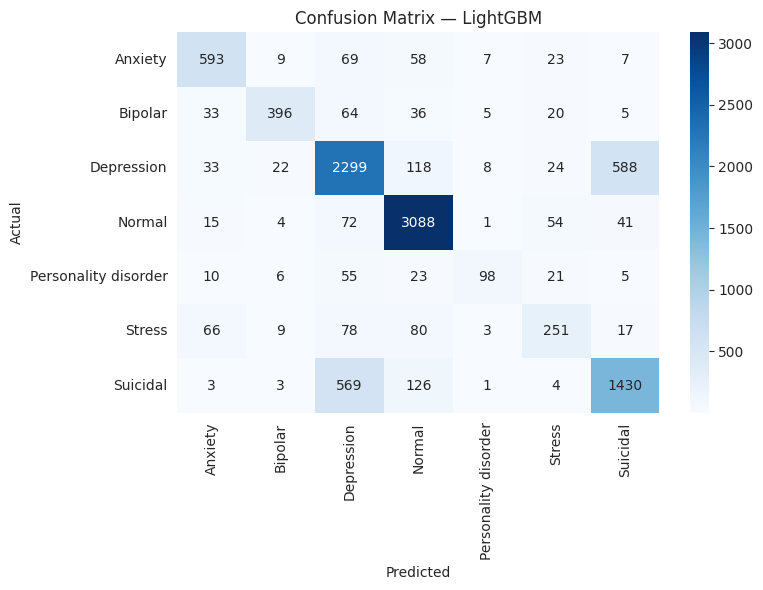

Macro AUC: 0.9450  95% CI [0.9408, 0.9487]
Saved → ./01_OriginalLabel/outputs/LightGBM_roc_curve.png


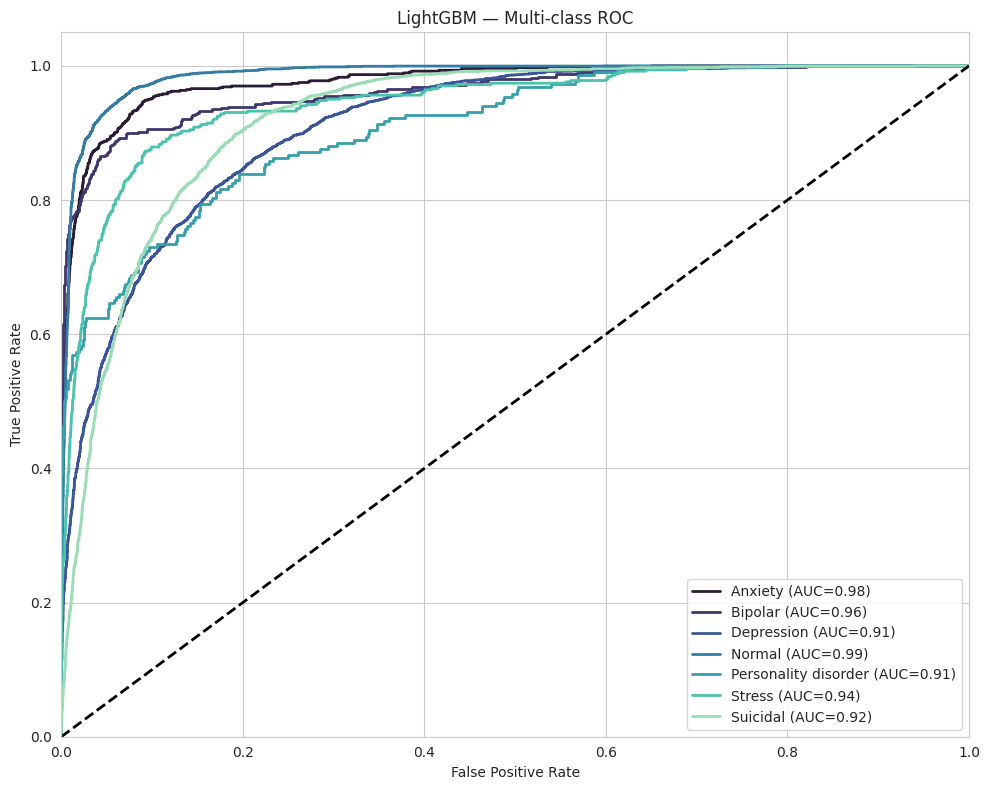

In [ ]:
evaluate_ml(best_model_lgbm, X_test_tfidf, y_test_ml, "LightGBM")

### Step 3: Model Interpretation

Saved → ./01_OriginalLabel/outputs/lightgbm_feature_importance.png


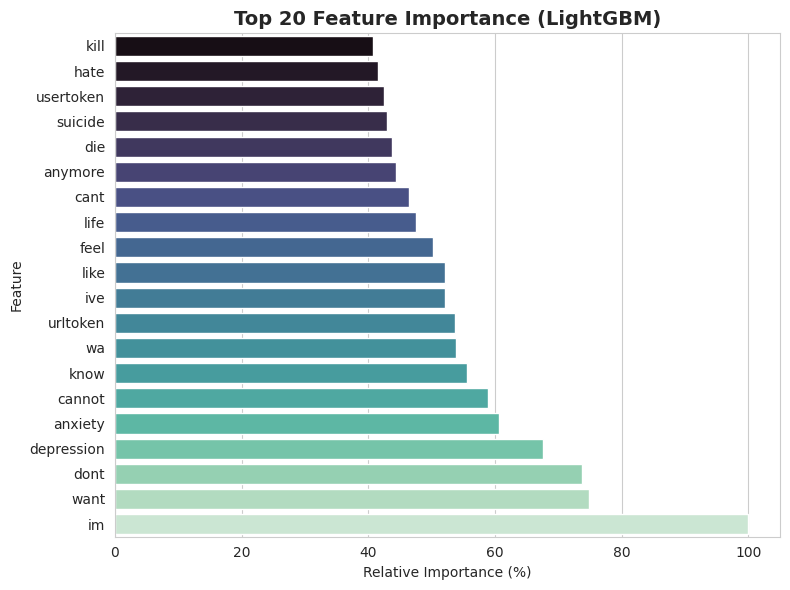

,Feature,Importance,Scaled
4512,im,414,100.000000
9651,want,310,74.879227
2765,dont,305,73.671498
2451,depression,280,67.632850
630,anxiety,251,60.628019
1455,cannot,244,58.937198
5033,know,230,55.555556
9621,wa,223,53.864734
9453,urltoken,222,53.623188
4887,ive,216,52.173913


In [ ]:
plot_feature_importance(best_model_lgbm.feature_importances_, feature_names_tfidf, "LightGBM")

## 3.4 Save Predictions for Machine Learning Models

In [ ]:
print("\nSaving ML predictions...")

y_true_str = df_test_ml[LABEL_COLUMN].astype(str).values
y_true_id  = label_encoder.transform(y_true_str)

lr_pred   = best_model_lr.predict(X_test_tfidf)
svm_pred  = best_model_svm.predict(X_test_tfidf)
rf_pred   = best_model_rf.predict(X_test_tfidf)
lgbm_pred = best_model_lgbm.predict(X_test_tfidf)

lr_proba   = best_model_lr.predict_proba(X_test_tfidf)
svm_proba  = best_model_svm.predict_proba(X_test_tfidf)
rf_proba   = best_model_rf.predict_proba(X_test_tfidf)
lgbm_proba = best_model_lgbm.predict_proba(X_test_tfidf)

class_names_ml = best_model_lr.classes_
assert np.array_equal(class_names_ml, best_model_svm.classes_)
assert np.array_equal(class_names_ml, best_model_rf.classes_)
assert np.array_equal(class_names_ml, best_model_lgbm.classes_)

# Build prediction DataFrame
if "id" in df_test_ml.columns:
    df_pred_ml = df_test_ml[["id", TEXT_COLUMN]].copy()
else:
    df_pred_ml = df_test_ml[[TEXT_COLUMN]].copy()
    df_pred_ml.insert(0, "id", df_test_ml.index)

df_pred_ml["true_label"]    = y_true_str
df_pred_ml["true_label_id"] = y_true_id
df_pred_ml["lr_pred"]       = lr_pred
df_pred_ml["svm_pred"]      = svm_pred
df_pred_ml["rf_pred"]       = rf_pred
df_pred_ml["lgbm_pred"]     = lgbm_pred

for i, cls in enumerate(class_names_ml):
    df_pred_ml[f"lr_prob_{cls}"]   = lr_proba[:, i]
    df_pred_ml[f"svm_prob_{cls}"]  = svm_proba[:, i]
    df_pred_ml[f"rf_prob_{cls}"]   = rf_proba[:, i]
    df_pred_ml[f"lgbm_prob_{cls}"] = lgbm_proba[:, i]

ml_pred_path = OUTPUT_PATH / "ml_models_predictions.csv"
df_pred_ml.to_csv(ml_pred_path, index=False)
print(f"Saved ML predictions → {ml_pred_path}")


Saving ML predictions...
Saved ML predictions → ./01_OriginalLabel/outputs/ml_models_predictions.csv


# 4. DL Models


## 4.0 Pre-processing \& data preparation for DL Models

In [ ]:
df_train_dl = df_clean[df_clean["split"] == "train"].copy()
df_val_dl   = df_clean[df_clean["split"] == "val"].copy()
df_test_dl  = df_clean[df_clean["split"] == "test"].copy()

train_labels_dl = df_train_dl[LABEL_COLUMN_ENCODED].tolist()
val_labels_dl   = df_val_dl[LABEL_COLUMN_ENCODED].tolist()
test_labels_dl  = df_test_dl[LABEL_COLUMN_ENCODED].tolist()

# ── GRU/CNN and Transformers all use augmented text (model_text) ──
train_texts_dl = df_train_dl[TEXT_COLUMN].fillna("").astype(str).tolist()
val_texts_dl   = df_val_dl[TEXT_COLUMN].fillna("").astype(str).tolist()
test_texts_dl  = df_test_dl[TEXT_COLUMN].fillna("").astype(str).tolist()

print(f"DL splits: train={len(train_texts_dl)}, val={len(val_texts_dl)}, test={len(test_texts_dl)}")

# ── Build shared vocabulary (GRU + CNN — from raw text) ──
# PAD=0, UNK=1, words start at 2
vocab_counter = Counter()
for text in train_texts_dl:
    vocab_counter.update(text.split())
most_common = [w for w, _ in vocab_counter.most_common(VOCAB_SIZE - 2)]  # -2 for PAD and UNK
word_to_index = {w: i + 2 for i, w in enumerate(most_common)}  # 0=PAD, 1=UNK
UNK_IDX = 1

print(f"Vocabulary: {len(word_to_index)} words + PAD(0) + UNK(1)")


def text_to_sequence(text, w2i, max_len=MAX_TOKEN_LENGTH):
    tokens = text.split()
    return [w2i.get(w, UNK_IDX) for w in tokens][:max_len]


# ── Convert & pad sequences (fixed length = MAX_TOKEN_LENGTH) ──
def build_padded_sequences(texts, w2i, max_len=MAX_TOKEN_LENGTH):
    seqs = []
    for t in texts:
        seq = text_to_sequence(t, w2i, max_len)
        # Pad to exactly max_len (not max-in-split)
        padded = seq + [0] * (max_len - len(seq))
        seqs.append(padded)
    return torch.tensor(seqs, dtype=torch.long)

train_seqs = build_padded_sequences(train_texts_dl, word_to_index)
val_seqs   = build_padded_sequences(val_texts_dl, word_to_index)
test_seqs  = build_padded_sequences(test_texts_dl, word_to_index)

train_labels_t = torch.tensor(train_labels_dl, dtype=torch.long)
val_labels_t   = torch.tensor(val_labels_dl, dtype=torch.long)
test_labels_t  = torch.tensor(test_labels_dl, dtype=torch.long)

print(f"Sequence shapes: train={train_seqs.shape}, val={val_seqs.shape}, test={test_seqs.shape}")

DL splits: train=31976, val=10517, test=10550
Vocabulary: 9998 words + PAD(0) + UNK(1)
Sequence shapes: train=torch.Size([31976, 200]), val=torch.Size([10517, 200]), test=torch.Size([10550, 200])


In [ ]:
# ── Dataset class (GRU + CNN) ────────────────────────────
class SeqDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = sequences
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {"input_ids": self.sequences[idx], "label": self.labels[idx]}


# ── DataLoaders (shared, with pin_memory) ────────────────
_loader_kw = dict(batch_size=BATCH_SIZE, num_workers=2,
                  pin_memory=True, persistent_workers=True)

train_loader_seq = DataLoader(SeqDataset(train_seqs, train_labels_t), shuffle=True, **_loader_kw)
val_loader_seq   = DataLoader(SeqDataset(val_seqs, val_labels_t), shuffle=False, **_loader_kw)
test_loader_seq  = DataLoader(SeqDataset(test_seqs, test_labels_t), shuffle=False, **_loader_kw)

# ── Class weights for DL training ────────────────────────
_cw = compute_class_weight("balanced", classes=np.unique(train_labels_dl), y=train_labels_dl)
class_weights_dl = torch.tensor(_cw, dtype=torch.float32).to(DEVICE)

## 4.1 Neural Network (GRU \& CNN)

### 4.1.1 Generic train + evaluation

In [ ]:
def train_seq_model(model, train_loader, val_loader, lr=1e-3,
                    max_epochs=20, patience=5):
    """Train a sequence model (GRU or CNN) with early stopping."""
    model.to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights_dl)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scaler = GradScaler(enabled=USE_FP16)

    best_f1, best_state, no_improve = -1.0, None, 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        losses = []
        for batch in train_loader:
            ids = batch["input_ids"].to(DEVICE, non_blocking=True)
            labels = batch["label"].to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            with autocast("cuda", enabled=USE_FP16):
                logits = model(ids)
                loss = criterion(logits, labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), SEQ_MAX_GRAD_NORM)
            scaler.step(optimizer)
            scaler.update()
            losses.append(loss.item())

        # Validate
        model.eval()
        val_preds, val_true = [], []
        with torch.no_grad():
            for batch in val_loader:
                ids = batch["input_ids"].to(DEVICE, non_blocking=True)
                labels = batch["label"]
                with autocast("cuda", enabled=USE_FP16):
                    logits = model(ids)
                val_preds.extend(logits.float().argmax(dim=1).cpu().numpy())
                val_true.extend(labels.numpy())

        val_f1 = f1_score(val_true, val_preds, average="weighted")
        val_acc = accuracy_score(val_true, val_preds)
        print(f"  Epoch {epoch}/{max_epochs} | Loss={np.mean(losses):.4f} | "
              f"Val F1={val_f1:.4f} | Val Acc={val_acc:.4f}")

        if val_f1 > best_f1:
            best_f1 = val_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"  Early stopping at epoch {epoch}.")
                break

    if best_state:
        model.load_state_dict(best_state)
    return best_f1, model

### 4.1.2 GRU

#### Step 1: Define GRU Model

In [ ]:
class GRUSentimentModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.gru = nn.GRU(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_ids):
        embedded = self.embedding(input_ids)
        _, hidden = self.gru(embedded)
        return self.fc(self.dropout(hidden[-1]))

#### Step 2: Hyperparameter Tuning

In [ ]:
RETRAIN = True
if RETRAIN:
    set_seed()
    print("\nTuning GRU...")
    start = time.time()

    MAX_EPOCHS_GRU = 20
    PATIENCE_GRU = 5

    gru_param_space = {
        "embedding_dim": (150, 300),
        "hidden_dim": (128, 384),
        "lr": (np.log10(1e-4), np.log10(1e-3)),  # log-uniform
    }

    best_f1_gru, best_params_gru, best_gru = 0, None, None

    for i in tqdm(range(N_ITERATIONS), desc="GRU Random Search"):
        hp = {
            "embedding_dim": int(np.random.uniform(*gru_param_space["embedding_dim"])),
            "hidden_dim": int(np.random.uniform(*gru_param_space["hidden_dim"])),
            "lr": float(10 ** np.random.uniform(*gru_param_space["lr"])),
        }

        model = GRUSentimentModel(
            vocab_size=VOCAB_SIZE, embedding_dim=hp["embedding_dim"],
            hidden_dim=hp["hidden_dim"], output_dim=NUM_CLASSES,
        )

        f1_val, model = train_seq_model(
            model, train_loader_seq, val_loader_seq,
            lr=hp["lr"], max_epochs=MAX_EPOCHS_GRU, patience=PATIENCE_GRU,
        )

        if f1_val > best_f1_gru:
            best_f1_gru = f1_val
            best_params_gru = hp
            best_gru = model

    print(f"GRU tuning: {time.time()-start:.1f}s | Best F1={best_f1_gru:.4f}")
    print(f"Best params: {best_params_gru}")

    torch.save(best_gru.state_dict(), MODEL_PATHS["gru"]["model"])
    with open(MODEL_PATHS["gru"]["params"], "w") as f:
        json.dump(best_params_gru, f, indent=2)
else:
    print("Loading GRU from disk...")
    with open(MODEL_PATHS["gru"]["params"]) as f:
        best_params_gru = json.load(f)
    best_gru = GRUSentimentModel(
        vocab_size=VOCAB_SIZE, embedding_dim=int(best_params_gru["embedding_dim"]),
        hidden_dim=int(best_params_gru["hidden_dim"]), output_dim=NUM_CLASSES,
    )
    best_gru.load_state_dict(torch.load(MODEL_PATHS["gru"]["model"], map_location=DEVICE))
    print(f"Loaded GRU from {MODEL_PATHS['gru']['model']}")



Tuning GRU...


GRU Random Search:   0%|          | 0/10 [00:00<?, ?it/s]

  Epoch 1/20 | Loss=1.9112 | Val F1=0.2721 | Val Acc=0.3808
  Epoch 2/20 | Loss=1.5386 | Val F1=0.5693 | Val Acc=0.5735
  Epoch 3/20 | Loss=1.1037 | Val F1=0.6716 | Val Acc=0.6740
  Epoch 4/20 | Loss=0.7230 | Val F1=0.7061 | Val Acc=0.6871
  Epoch 5/20 | Loss=0.5452 | Val F1=0.7367 | Val Acc=0.7267
  Epoch 6/20 | Loss=0.4166 | Val F1=0.7292 | Val Acc=0.7189
  Epoch 7/20 | Loss=0.3525 | Val F1=0.7482 | Val Acc=0.7455
  Epoch 8/20 | Loss=0.2826 | Val F1=0.7451 | Val Acc=0.7452
  Epoch 9/20 | Loss=0.2488 | Val F1=0.7444 | Val Acc=0.7412
  Epoch 10/20 | Loss=0.2136 | Val F1=0.7447 | Val Acc=0.7445
  Epoch 11/20 | Loss=0.1895 | Val F1=0.7394 | Val Acc=0.7363


GRU Random Search:  10%|█         | 1/10 [00:38<05:47, 38.56s/it]

  Epoch 12/20 | Loss=0.1662 | Val F1=0.7391 | Val Acc=0.7364
  Early stopping at epoch 12.
  Epoch 1/20 | Loss=1.9218 | Val F1=0.2491 | Val Acc=0.3582
  Epoch 2/20 | Loss=1.8345 | Val F1=0.3251 | Val Acc=0.3603
  Epoch 3/20 | Loss=1.7173 | Val F1=0.4194 | Val Acc=0.4553
  Epoch 4/20 | Loss=1.5911 | Val F1=0.5037 | Val Acc=0.5290
  Epoch 5/20 | Loss=1.3964 | Val F1=0.5024 | Val Acc=0.5230
  Epoch 6/20 | Loss=1.3178 | Val F1=0.5301 | Val Acc=0.5481
  Epoch 7/20 | Loss=1.2689 | Val F1=0.5371 | Val Acc=0.5600
  Epoch 8/20 | Loss=1.2174 | Val F1=0.6068 | Val Acc=0.5974
  Epoch 9/20 | Loss=1.1449 | Val F1=0.6109 | Val Acc=0.6122
  Epoch 10/20 | Loss=1.0608 | Val F1=0.5948 | Val Acc=0.6115
  Epoch 11/20 | Loss=0.9569 | Val F1=0.6437 | Val Acc=0.6462
  Epoch 12/20 | Loss=0.8626 | Val F1=0.6581 | Val Acc=0.6566
  Epoch 13/20 | Loss=0.7994 | Val F1=0.6567 | Val Acc=0.6600
  Epoch 14/20 | Loss=0.7558 | Val F1=0.6605 | Val Acc=0.6612
  Epoch 15/20 | Loss=0.7053 | Val F1=0.6697 | Val Acc=0.6687
  E

...

  Epoch 20/20 | Loss=0.6024 | Val F1=0.6930 | Val Acc=0.6890
  Epoch 1/20 | Loss=1.9088 | Val F1=0.2740 | Val Acc=0.3763
  Epoch 2/20 | Loss=1.8192 | Val F1=0.4421 | Val Acc=0.4905
  Epoch 3/20 | Loss=1.5540 | Val F1=0.4612 | Val Acc=0.5135
  Epoch 4/20 | Loss=1.3552 | Val F1=0.5641 | Val Acc=0.5625
  Epoch 5/20 | Loss=1.2763 | Val F1=0.5924 | Val Acc=0.5812
  Epoch 6/20 | Loss=1.1429 | Val F1=0.6246 | Val Acc=0.6044
  Epoch 7/20 | Loss=0.9440 | Val F1=0.6660 | Val Acc=0.6478
  Epoch 8/20 | Loss=0.8243 | Val F1=0.6759 | Val Acc=0.6660
  Epoch 9/20 | Loss=0.7319 | Val F1=0.6810 | Val Acc=0.6806
  Epoch 10/20 | Loss=0.6826 | Val F1=0.6994 | Val Acc=0.6968
  Epoch 11/20 | Loss=0.6182 | Val F1=0.7011 | Val Acc=0.7000
  Epoch 12/20 | Loss=0.5734 | Val F1=0.6895 | Val Acc=0.6940
  Epoch 13/20 | Loss=0.5413 | Val F1=0.7249 | Val Acc=0.7240
  Epoch 14/20 | Loss=0.5143 | Val F1=0.7276 | Val Acc=0.7243
  Epoch 15/20 | Loss=0.4818 | Val F1=0.7307 | Val Acc=0.7288
  Epoch 16/20 | Loss=0.4672 | Val

GRU Random Search:  90%|█████████ | 9/10 [07:15<00:53, 53.95s/it]

  Epoch 20/20 | Loss=0.4044 | Val F1=0.7360 | Val Acc=0.7345
  Epoch 1/20 | Loss=1.9353 | Val F1=0.2497 | Val Acc=0.3607
  Epoch 2/20 | Loss=1.8998 | Val F1=0.2656 | Val Acc=0.3706
  Epoch 3/20 | Loss=1.8437 | Val F1=0.3965 | Val Acc=0.4694
  Epoch 4/20 | Loss=1.7596 | Val F1=0.4373 | Val Acc=0.4811
  Epoch 5/20 | Loss=1.7192 | Val F1=0.4086 | Val Acc=0.4610
  Epoch 6/20 | Loss=1.6820 | Val F1=0.4311 | Val Acc=0.4725
  Epoch 7/20 | Loss=1.6254 | Val F1=0.4495 | Val Acc=0.4963
  Epoch 8/20 | Loss=1.5216 | Val F1=0.4778 | Val Acc=0.5196
  Epoch 9/20 | Loss=1.4282 | Val F1=0.5001 | Val Acc=0.5218
  Epoch 10/20 | Loss=1.3733 | Val F1=0.5238 | Val Acc=0.5171
  Epoch 11/20 | Loss=1.3211 | Val F1=0.5287 | Val Acc=0.5353
  Epoch 12/20 | Loss=1.2883 | Val F1=0.5283 | Val Acc=0.5434
  Epoch 13/20 | Loss=1.2589 | Val F1=0.5332 | Val Acc=0.5438
  Epoch 14/20 | Loss=1.2367 | Val F1=0.5315 | Val Acc=0.5183
  Epoch 15/20 | Loss=1.2109 | Val F1=0.5618 | Val Acc=0.5613
  Epoch 16/20 | Loss=1.1831 | Val

GRU Random Search: 100%|██████████| 10/10 [08:26<00:00, 50.62s/it]

  Epoch 20/20 | Loss=1.0891 | Val F1=0.5544 | Val Acc=0.5729
GRU tuning: 506.2s | Best F1=0.7552
Best params: {'embedding_dim': 248, 'hidden_dim': 254, 'lr': 0.0009209550194493248}


#### Step 3: Model Evaluation

Eval GRU: 100%|██████████| 83/83 [00:00<00:00, 221.31it/s]



Evaluation: GRU
                      precision    recall  f1-score   support

             Anxiety     0.7358    0.7781    0.7563       766
              Normal     0.9203    0.9029    0.9115      3275
          Depression     0.7707    0.6381    0.6982      3092
            Suicidal     0.6328    0.7795    0.6986      2136
              Stress     0.4711    0.6151    0.5336       504
             Bipolar     0.7925    0.6834    0.7339       559
Personality disorder     0.5306    0.4771    0.5024       218

            accuracy                         0.7571     10550
           macro avg     0.6934    0.6963    0.6906     10550
        weighted avg     0.7686    0.7571    0.7587     10550

Weighted F1: 0.7584  95% CI [0.7499, 0.7665]
Saved → ./01_OriginalLabel/outputs/GRU_confusion_matrix.png


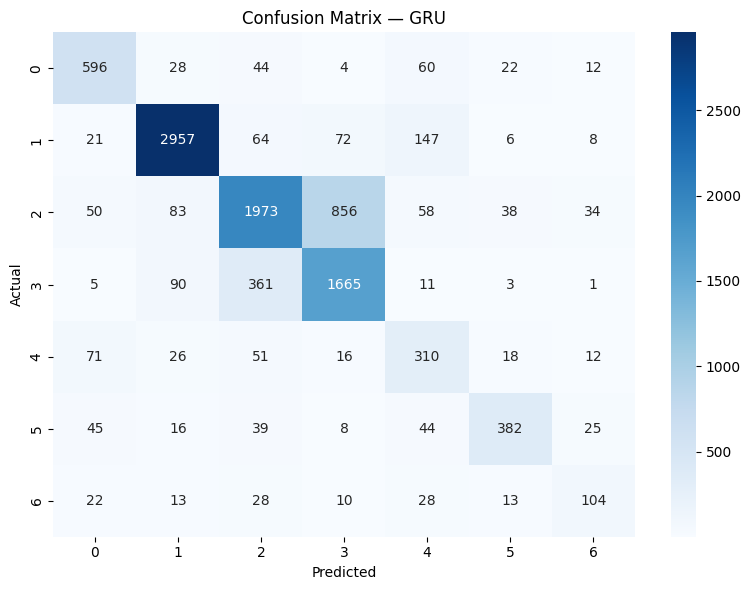

Macro AUC: 0.9449  95% CI [0.9409, 0.9489]
Saved → ./01_OriginalLabel/outputs/GRU_roc_curve.png


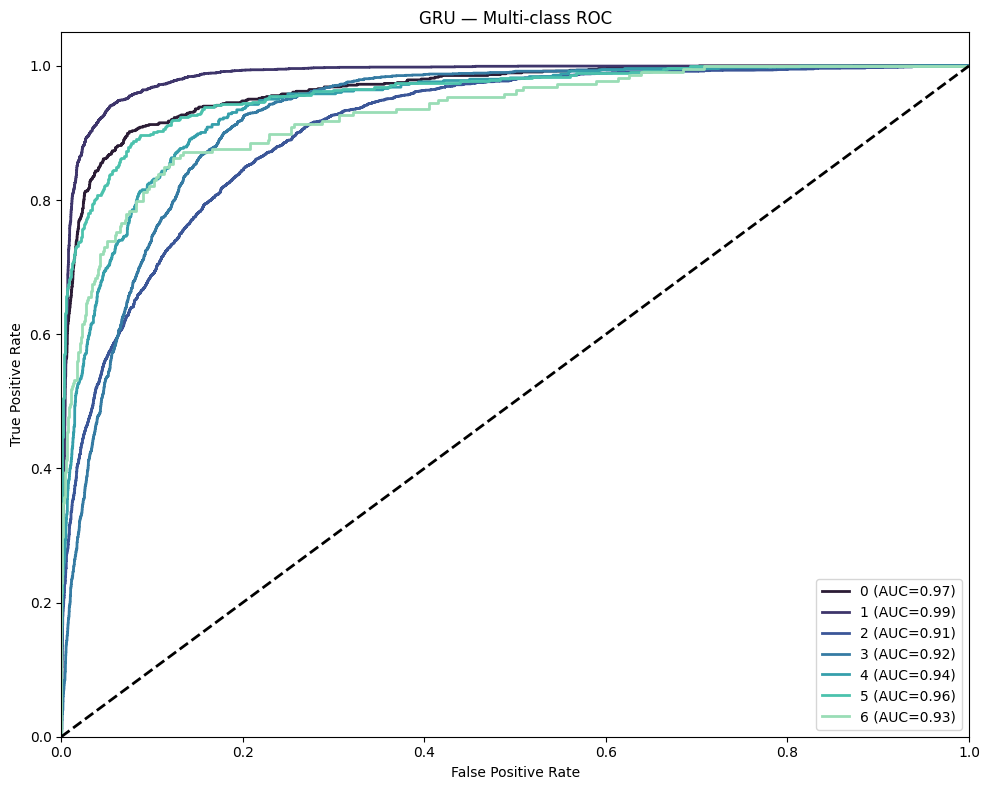

In [ ]:
gru_preds, gru_probs, y_true_gru = evaluate_pytorch(
    best_gru, test_loader_seq, label_encoder, "GRU", use_attention_mask=False
)

### 4.1.3 CNN

### 4.2.2 CNN Modeling

#### Step 1: Define CNN Model

In [ ]:
class CNNSentimentModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, num_filters, filter_sizes,
                 output_dim, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.convs = nn.ModuleList([
            nn.Conv1d(embedding_dim, num_filters, fs) for fs in filter_sizes
        ])
        self.fc = nn.Linear(num_filters * len(filter_sizes), output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_ids):
        x = self.embedding(input_ids).permute(0, 2, 1)  # [B, E, L]
        pooled = [torch.relu(conv(x)).max(dim=2).values for conv in self.convs]
        cat = torch.cat(pooled, dim=1)
        return self.fc(self.dropout(cat))

#### Step 2: Hyperparameter Tuning

In [ ]:
RETRAIN = True

FILTER_SIZES = [3, 4, 5]

if RETRAIN:
    set_seed()
    print("\nTuning CNN...")
    start = time.time()

    MAX_EPOCHS_CNN = 20
    PATIENCE_CNN = 5

    cnn_param_space = {
        "embedding_dim": (150, 300),     # uniform
        "num_filters":  (80, 200),       # filters per kernel size
        "lr": (np.log10(1e-4), np.log10(1e-3)),  # log-uniform
    }

    best_f1_cnn, best_params_cnn, best_cnn = 0, None, None

    for i in tqdm(range(N_ITERATIONS), desc="CNN Random Search"):
        hp = {
            "embedding_dim": int(np.random.uniform(*cnn_param_space["embedding_dim"])),
            "num_filters": int(np.random.uniform(*cnn_param_space["num_filters"])),
            "lr": float(10 ** np.random.uniform(*cnn_param_space["lr"])),
        }

        model = CNNSentimentModel(
            vocab_size=VOCAB_SIZE, embedding_dim=hp["embedding_dim"],
            num_filters=hp["num_filters"], filter_sizes=FILTER_SIZES,
            output_dim=NUM_CLASSES,
        )

        f1_val, model = train_seq_model(
            model, train_loader_seq, val_loader_seq,
            lr=hp["lr"], max_epochs=MAX_EPOCHS_CNN, patience=PATIENCE_CNN,
        )

        if f1_val > best_f1_cnn:
            best_f1_cnn = f1_val
            best_params_cnn = hp
            best_cnn = model

    print(f"CNN tuning: {time.time()-start:.1f}s | Best F1={best_f1_cnn:.4f}")
    print(f"Best params: {best_params_cnn}")

    torch.save(best_cnn.state_dict(), MODEL_PATHS["cnn"]["model"])
    with open(MODEL_PATHS["cnn"]["params"], "w") as f:
        json.dump(best_params_cnn, f, indent=2)
else:
    print("Loading CNN from disk...")
    with open(MODEL_PATHS["cnn"]["params"]) as f:
        best_params_cnn = json.load(f)
    best_cnn = CNNSentimentModel(
        vocab_size=VOCAB_SIZE, embedding_dim=int(best_params_cnn["embedding_dim"]),
        num_filters=int(best_params_cnn["num_filters"]), filter_sizes=FILTER_SIZES,
        output_dim=NUM_CLASSES,
    )
    best_cnn.load_state_dict(torch.load(MODEL_PATHS["cnn"]["model"], map_location=DEVICE))
    print(f"Loaded CNN from {MODEL_PATHS['cnn']['model']}")


Tuning CNN...


CNN Random Search:   0%|          | 0/10 [00:00<?, ?it/s]

  Epoch 1/20 | Loss=1.3607 | Val F1=0.7036 | Val Acc=0.6912
  Epoch 2/20 | Loss=0.8746 | Val F1=0.6910 | Val Acc=0.6996
  Epoch 3/20 | Loss=0.6912 | Val F1=0.7383 | Val Acc=0.7328
  Epoch 4/20 | Loss=0.5745 | Val F1=0.7290 | Val Acc=0.7292
  Epoch 5/20 | Loss=0.4880 | Val F1=0.7538 | Val Acc=0.7482
  Epoch 6/20 | Loss=0.4228 | Val F1=0.7481 | Val Acc=0.7477
  Epoch 7/20 | Loss=0.3643 | Val F1=0.7491 | Val Acc=0.7504
  Epoch 8/20 | Loss=0.3218 | Val F1=0.7245 | Val Acc=0.7298
  Epoch 9/20 | Loss=0.2980 | Val F1=0.7532 | Val Acc=0.7544
  Epoch 10/20 | Loss=0.2660 | Val F1=0.7577 | Val Acc=0.7572
  Epoch 11/20 | Loss=0.2334 | Val F1=0.7577 | Val Acc=0.7591
  Epoch 12/20 | Loss=0.2156 | Val F1=0.7342 | Val Acc=0.7381
  Epoch 13/20 | Loss=0.1963 | Val F1=0.7467 | Val Acc=0.7476
  Epoch 14/20 | Loss=0.1777 | Val F1=0.7533 | Val Acc=0.7543
  Epoch 15/20 | Loss=0.1634 | Val F1=0.7325 | Val Acc=0.7357


CNN Random Search:  10%|█         | 1/10 [00:24<03:41, 24.61s/it]

  Epoch 16/20 | Loss=0.1514 | Val F1=0.7505 | Val Acc=0.7517
  Early stopping at epoch 16.
  Epoch 1/20 | Loss=1.7022 | Val F1=0.5925 | Val Acc=0.5924
  Epoch 2/20 | Loss=1.2433 | Val F1=0.6659 | Val Acc=0.6666
  Epoch 3/20 | Loss=1.0185 | Val F1=0.6892 | Val Acc=0.6896
  Epoch 4/20 | Loss=0.8912 | Val F1=0.7166 | Val Acc=0.7140
  Epoch 5/20 | Loss=0.8096 | Val F1=0.7122 | Val Acc=0.7143
  Epoch 6/20 | Loss=0.7451 | Val F1=0.7290 | Val Acc=0.7279
  Epoch 7/20 | Loss=0.6825 | Val F1=0.7347 | Val Acc=0.7340
  Epoch 8/20 | Loss=0.6369 | Val F1=0.7408 | Val Acc=0.7392
  Epoch 9/20 | Loss=0.5932 | Val F1=0.7389 | Val Acc=0.7342
  Epoch 10/20 | Loss=0.5613 | Val F1=0.7467 | Val Acc=0.7458
  Epoch 11/20 | Loss=0.5293 | Val F1=0.7431 | Val Acc=0.7424
  Epoch 12/20 | Loss=0.4933 | Val F1=0.7479 | Val Acc=0.7463
  Epoch 13/20 | Loss=0.4681 | Val F1=0.7432 | Val Acc=0.7430
  Epoch 14/20 | Loss=0.4460 | Val F1=0.7415 | Val Acc=0.7437
  Epoch 15/20 | Loss=0.4294 | Val F1=0.7438 | Val Acc=0.7436
  E

...

  Epoch 20/20 | Loss=0.3305 | Val F1=0.7629 | Val Acc=0.7630
  Epoch 1/20 | Loss=1.5765 | Val F1=0.6013 | Val Acc=0.6065
  Epoch 2/20 | Loss=1.0657 | Val F1=0.6990 | Val Acc=0.6954
  Epoch 3/20 | Loss=0.8604 | Val F1=0.7065 | Val Acc=0.7057
  Epoch 4/20 | Loss=0.7377 | Val F1=0.7375 | Val Acc=0.7324
  Epoch 5/20 | Loss=0.6424 | Val F1=0.7258 | Val Acc=0.7227
  Epoch 6/20 | Loss=0.5810 | Val F1=0.7447 | Val Acc=0.7422
  Epoch 7/20 | Loss=0.5198 | Val F1=0.7544 | Val Acc=0.7515
  Epoch 8/20 | Loss=0.4713 | Val F1=0.7385 | Val Acc=0.7389
  Epoch 9/20 | Loss=0.4366 | Val F1=0.7548 | Val Acc=0.7547
  Epoch 10/20 | Loss=0.4008 | Val F1=0.7611 | Val Acc=0.7605
  Epoch 11/20 | Loss=0.3745 | Val F1=0.7614 | Val Acc=0.7619
  Epoch 12/20 | Loss=0.3495 | Val F1=0.7671 | Val Acc=0.7669
  Epoch 13/20 | Loss=0.3277 | Val F1=0.7374 | Val Acc=0.7417
  Epoch 14/20 | Loss=0.3100 | Val F1=0.7666 | Val Acc=0.7668
  Epoch 15/20 | Loss=0.2931 | Val F1=0.7664 | Val Acc=0.7660
  Epoch 16/20 | Loss=0.2732 | Val

CNN Random Search:  90%|█████████ | 9/10 [04:04<00:29, 29.82s/it]

  Epoch 20/20 | Loss=0.2222 | Val F1=0.7694 | Val Acc=0.7685
  Epoch 1/20 | Loss=1.8112 | Val F1=0.5110 | Val Acc=0.5101
  Epoch 2/20 | Loss=1.4690 | Val F1=0.5987 | Val Acc=0.5958
  Epoch 3/20 | Loss=1.2920 | Val F1=0.6235 | Val Acc=0.6230
  Epoch 4/20 | Loss=1.1631 | Val F1=0.6585 | Val Acc=0.6584
  Epoch 5/20 | Loss=1.0579 | Val F1=0.6759 | Val Acc=0.6724
  Epoch 6/20 | Loss=0.9729 | Val F1=0.6823 | Val Acc=0.6822
  Epoch 7/20 | Loss=0.9122 | Val F1=0.6862 | Val Acc=0.6850
  Epoch 8/20 | Loss=0.8627 | Val F1=0.7019 | Val Acc=0.7029
  Epoch 9/20 | Loss=0.8170 | Val F1=0.7047 | Val Acc=0.7066
  Epoch 10/20 | Loss=0.7778 | Val F1=0.7077 | Val Acc=0.7110
  Epoch 11/20 | Loss=0.7451 | Val F1=0.7252 | Val Acc=0.7234
  Epoch 12/20 | Loss=0.7110 | Val F1=0.7270 | Val Acc=0.7270
  Epoch 13/20 | Loss=0.6829 | Val F1=0.7313 | Val Acc=0.7299
  Epoch 14/20 | Loss=0.6565 | Val F1=0.7360 | Val Acc=0.7332
  Epoch 15/20 | Loss=0.6287 | Val F1=0.7344 | Val Acc=0.7333
  Epoch 16/20 | Loss=0.6044 | Val

CNN Random Search: 100%|██████████| 10/10 [04:34<00:00, 27.41s/it]

  Epoch 20/20 | Loss=0.5356 | Val F1=0.7400 | Val Acc=0.7405
CNN tuning: 274.1s | Best F1=0.7694
Best params: {'embedding_dim': 287, 'num_filters': 193, 'lr': 0.00018953847119167257}


#### Step 3: Model Evaluation

Eval CNN: 100%|██████████| 83/83 [00:00<00:00, 447.29it/s]



Evaluation: CNN
                      precision    recall  f1-score   support

             Anxiety     0.7743    0.7702    0.7723       766
              Normal     0.9156    0.9240    0.9198      3275
          Depression     0.7646    0.6827    0.7213      3092
            Suicidal     0.6730    0.7439    0.7067      2136
              Stress     0.4905    0.6687    0.5659       504
             Bipolar     0.8041    0.6977    0.7471       559
Personality disorder     0.5979    0.5183    0.5553       218

            accuracy                         0.7731     10550
           macro avg     0.7171    0.7151    0.7126     10550
        weighted avg     0.7792    0.7731    0.7742     10550

Weighted F1: 0.7740  95% CI [0.7655, 0.7824]
Saved → ./01_OriginalLabel/outputs/CNN_confusion_matrix.png


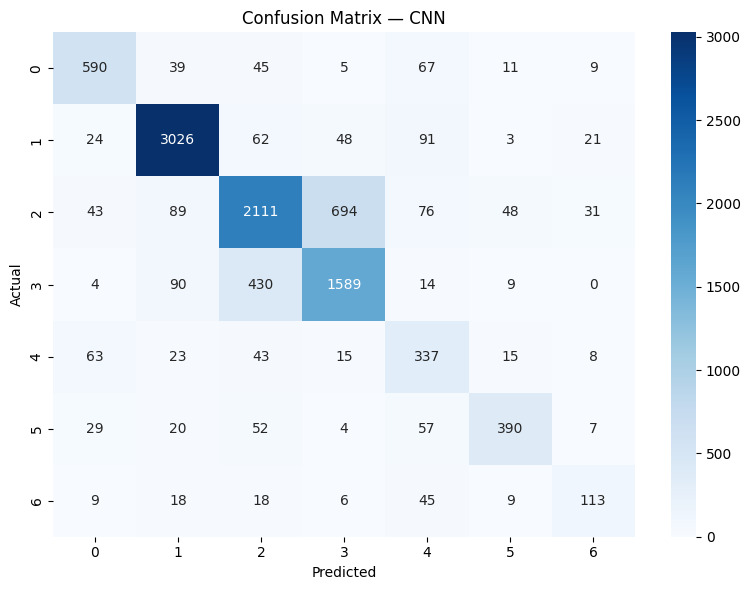

Macro AUC: 0.9561  95% CI [0.9530, 0.9593]
Saved → ./01_OriginalLabel/outputs/CNN_roc_curve.png


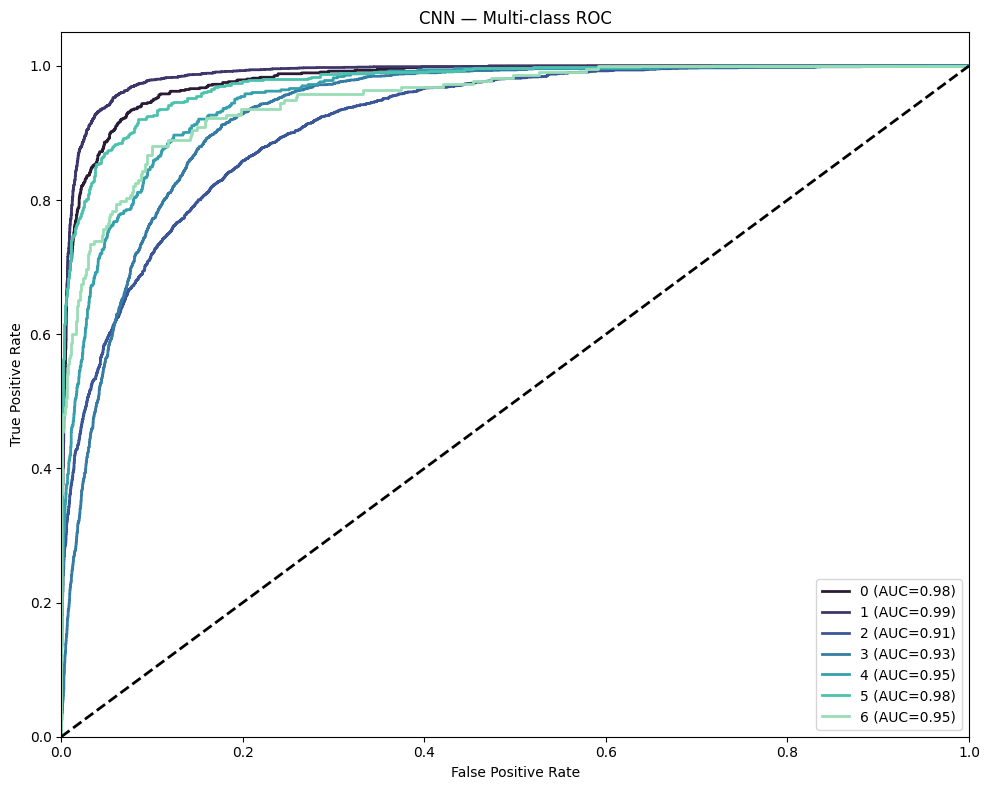

In [ ]:
cnn_preds, cnn_probs, y_true_cnn = evaluate_pytorch(
    best_cnn, test_loader_seq, label_encoder, "CNN", use_attention_mask=False
)

## 4.2 Transformer

### 4.2.1 Generic transformer train function

In [ ]:
def train_transformer(model, train_loader, val_loader,
                      lr=2e-5, max_epochs=6, patience=2):
    """Fine-tune a HuggingFace transformer with FP16, grad clip, OneCycleLR."""
    model.to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    total_steps = max_epochs * len(train_loader)
    scheduler = OneCycleLR(optimizer, max_lr=lr, total_steps=total_steps, pct_start=0.1)
    criterion = nn.CrossEntropyLoss(weight=class_weights_dl)
    scaler = GradScaler(enabled=USE_FP16)

    best_f1, best_state, no_improve = -1.0, None, 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        losses = []
        for batch in train_loader:
            ids  = batch["input_ids"].to(DEVICE, non_blocking=True)
            mask = batch["attention_mask"].to(DEVICE, non_blocking=True)
            labels = batch["label"].to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            with autocast("cuda", enabled=USE_FP16):
                outputs = model(input_ids=ids, attention_mask=mask)
                logits = outputs.logits if hasattr(outputs, "logits") else outputs
                loss = criterion(logits, labels)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            losses.append(loss.item())

        # Validate
        model.eval()
        val_preds, val_true = [], []
        with torch.no_grad():
            for batch in val_loader:
                ids  = batch["input_ids"].to(DEVICE, non_blocking=True)
                mask = batch["attention_mask"].to(DEVICE, non_blocking=True)
                with autocast("cuda", enabled=USE_FP16):
                    out = model(input_ids=ids, attention_mask=mask)
                logits = out.logits if hasattr(out, "logits") else out
                val_preds.extend(logits.float().argmax(dim=1).cpu().numpy())
                val_true.extend(batch["label"].numpy())

        val_f1 = f1_score(val_true, val_preds, average="weighted")
        print(f"  Epoch {epoch}/{max_epochs} | Loss={np.mean(losses):.4f} | Val F1={val_f1:.4f}")

        if val_f1 > best_f1:
            best_f1 = val_f1
            raw = model._orig_mod if hasattr(model, "_orig_mod") else model
            best_state = {k: v.cpu().clone() for k, v in raw.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"  Early stopping at epoch {epoch}.")
                break

    raw = model._orig_mod if hasattr(model, "_orig_mod") else model
    if best_state:
        raw.load_state_dict(best_state)
    return best_f1, raw

### 4.2.2 ALBERT

#### Step 1: Data Preparation

In [ ]:
print("\nPre-tokenizing for ALBERT...")
albert_tokenizer = AutoTokenizer.from_pretrained("albert-base-v2")


def batch_tokenize(texts, tokenizer, max_len, batch_size=512):
    all_ids, all_masks = [], []
    for i in range(0, len(texts), batch_size):
        enc = tokenizer(
            texts[i:i+batch_size], max_length=max_len,
            truncation=True, padding="max_length", return_tensors="pt",
        )
        all_ids.append(enc["input_ids"])
        all_masks.append(enc["attention_mask"])
    return torch.cat(all_ids), torch.cat(all_masks)


# Use same text lists as DL
train_ids_albert, train_masks_albert = batch_tokenize(train_texts_dl, albert_tokenizer, MAX_TOKEN_LENGTH)
val_ids_albert, val_masks_albert     = batch_tokenize(val_texts_dl, albert_tokenizer, MAX_TOKEN_LENGTH)
test_ids_albert, test_masks_albert   = batch_tokenize(test_texts_dl, albert_tokenizer, MAX_TOKEN_LENGTH)
print(f"ALBERT tokens: train={train_ids_albert.shape}")


# ── Cached dataset for transformers ──────────────────────
class TransformerDataset(Dataset):
    def __init__(self, input_ids, attention_mask, labels):
        self.input_ids = input_ids
        self.attention_mask = attention_mask
        self.labels = torch.tensor(np.asarray(labels, dtype=np.int64))

    def __len__(self):
        return self.input_ids.shape[0]

    def __getitem__(self, idx):
        return {
            "input_ids": self.input_ids[idx],
            "attention_mask": self.attention_mask[idx],
            "label": self.labels[idx],
        }


_tf_loader_kw = dict(batch_size=BATCH_SIZE, num_workers=2,
                     pin_memory=True, persistent_workers=True, prefetch_factor=4)

train_loader_albert = DataLoader(
    TransformerDataset(train_ids_albert, train_masks_albert, train_labels_dl),
    shuffle=True, **_tf_loader_kw)
val_loader_albert = DataLoader(
    TransformerDataset(val_ids_albert, val_masks_albert, val_labels_dl),
    shuffle=False, **_tf_loader_kw)
test_loader_albert = DataLoader(
    TransformerDataset(test_ids_albert, test_masks_albert, test_labels_dl),
    shuffle=False, **_tf_loader_kw)


Pre-tokenizing for ALBERT...


config.json:   0%|          | 0.00/684 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/760k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.31M [00:00<?, ?B/s]

ALBERT tokens: train=torch.Size([31976, 200])


#### Step 2: Hyperparameter Tuning

In [ ]:
RETRAIN = True

if RETRAIN:
    set_seed()
    print("\nTuning ALBERT...")
    start = time.time()

    albert_param_space = {
        "lr": (np.log10(1e-5), np.log10(3e-5)),
        "epochs": (4, 10),
        "dropout": (0.0, 0.25),
    }

    best_f1_albert, best_params_albert, best_albert = 0, None, None

    for i in tqdm(range(N_ITERATIONS), desc="ALBERT Random Search"):
        hp = {
            "lr": float(10 ** np.random.uniform(*albert_param_space["lr"])),
            "epochs": int(np.random.randint(*albert_param_space["epochs"])),
            "dropout": float(np.random.uniform(*albert_param_space["dropout"])),
        }

        model = AlbertForSequenceClassification.from_pretrained(
            "albert-base-v2", num_labels=NUM_CLASSES,
            classifier_dropout_prob=hp["dropout"],
        )

        if TORCH_COMPILE_OK:
            model = torch.compile(model, mode="reduce-overhead")

        f1_val, model = train_transformer(
            model, train_loader_albert, val_loader_albert,
            lr=hp["lr"], max_epochs=hp["epochs"], patience=3,
        )

        if f1_val > best_f1_albert:
            best_f1_albert = f1_val
            best_params_albert = hp
            best_albert = model

        del model
        gc.collect()
        torch.cuda.empty_cache()

    print(f"ALBERT tuning: {time.time()-start:.1f}s | Best F1={best_f1_albert:.4f}")
    print(f"Best params: {best_params_albert}")

    torch.save(best_albert.state_dict(), MODEL_PATHS["albert"]["model"])
else:
    print("Loading ALBERT from disk...")
    best_albert = AlbertForSequenceClassification.from_pretrained(
        "albert-base-v2", num_labels=NUM_CLASSES,
    )
    best_albert.load_state_dict(torch.load(MODEL_PATHS["albert"]["model"], map_location=DEVICE))
    print(f"Loaded ALBERT from {MODEL_PATHS['albert']['model']}")


Tuning ALBERT...


ALBERT Random Search:   0%|          | 0/10 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/47.4M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

AlbertForSequenceClassification LOAD REPORT from: albert-base-v2
Key                          | Status     | 
-----------------------------+------------+-
predictions.dense.weight     | UNEXPECTED | 
predictions.LayerNorm.weight | UNEXPECTED | 
predictions.LayerNorm.bias   | UNEXPECTED | 
predictions.bias             | UNEXPECTED | 
predictions.dense.bias       | UNEXPECTED | 
predictions.decoder.bias     | UNEXPECTED | 
classifier.weight            | MISSING    | 
classifier.bias              | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

AlbertForSequenceClassification LOAD REPORT from: albert-base-v2
Key                          | Status     | 
-----------------------------+------------+-
predictions.dense.weight     | UNEXPECTED | 
predictions.LayerNorm.weight | UNEXPECTED | 
predictions.LayerNorm.bias   | UNEXPECTED | 
predictions.bias             | UNEXPECTED | 
predictions.dense.bias       | UNEXPECTED | 
predictions.decoder.bias     | UNEXPECTED | 
classifier.weight            | MISSING    | 
classifier.bias              | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/9 | Loss=1.3939 | Val F1=0.7089
  Epoch 2/9 | Loss=0.7034 | Val F1=0.7545
  Epoch 3/9 | Loss=0.5236 | Val F1=0.7798
  Epoch 4/9 | Loss=0.3970 | Val F1=0.7737
  Epoch 5/9 | Loss=0.2940 | Val F1=0.8013
  Epoch 6/9 | Loss=0.2217 | Val F1=0.8058
  Epoch 7/9 | Loss=0.1645 | Val F1=0.8035
  Epoch 8/9 | Loss=0.1216 | Val F1=0.8022
  Epoch 9/9 | Loss=0.1004 | Val F1=0.8011
  Early stopping at epoch 9.


ALBERT Random Search: 100%|██████████| 10/10 [1:01:24<00:00, 368.43s/it]

ALBERT tuning: 3684.3s | Best F1=0.8058
Best params: {'lr': 2.9768448441450054e-05, 'epochs': 9, 'dropout': 0.2365358833708563}


#### Step 3: Model Evaluation

Eval ALBERT: 100%|██████████| 83/83 [00:06<00:00, 11.89it/s]



Evaluation: ALBERT
                      precision    recall  f1-score   support

             Anxiety     0.8527    0.8238    0.8380       766
              Normal     0.9416    0.9496    0.9456      3275
          Depression     0.8054    0.7028    0.7506      3092
            Suicidal     0.6856    0.7870    0.7328      2136
              Stress     0.7299    0.6488    0.6870       504
             Bipolar     0.7181    0.8569    0.7814       559
Personality disorder     0.6281    0.6972    0.6609       218

            accuracy                         0.8107     10550
           macro avg     0.7659    0.7809    0.7709     10550
        weighted avg     0.8150    0.8107    0.8106     10550

Weighted F1: 0.8105  95% CI [0.8033, 0.8181]
Saved → ./01_OriginalLabel/outputs/ALBERT_confusion_matrix.png


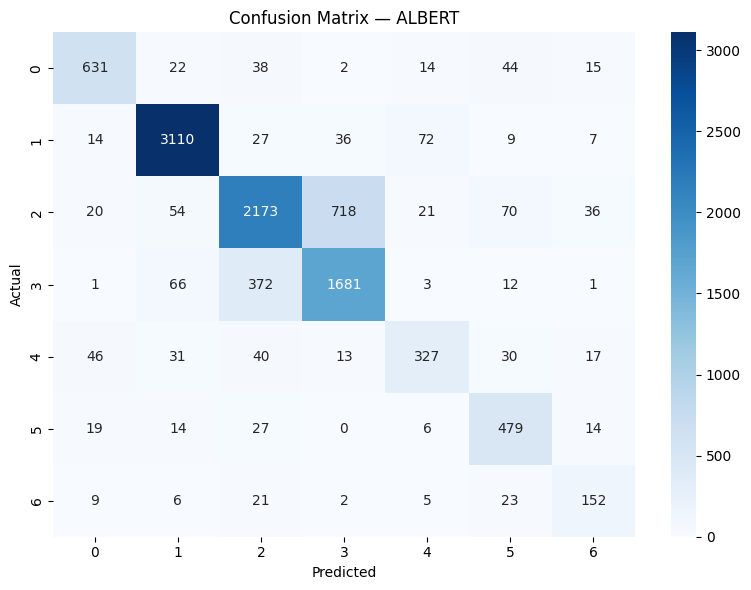

Macro AUC: 0.9691  95% CI [0.9668, 0.9714]
Saved → ./01_OriginalLabel/outputs/ALBERT_roc_curve.png


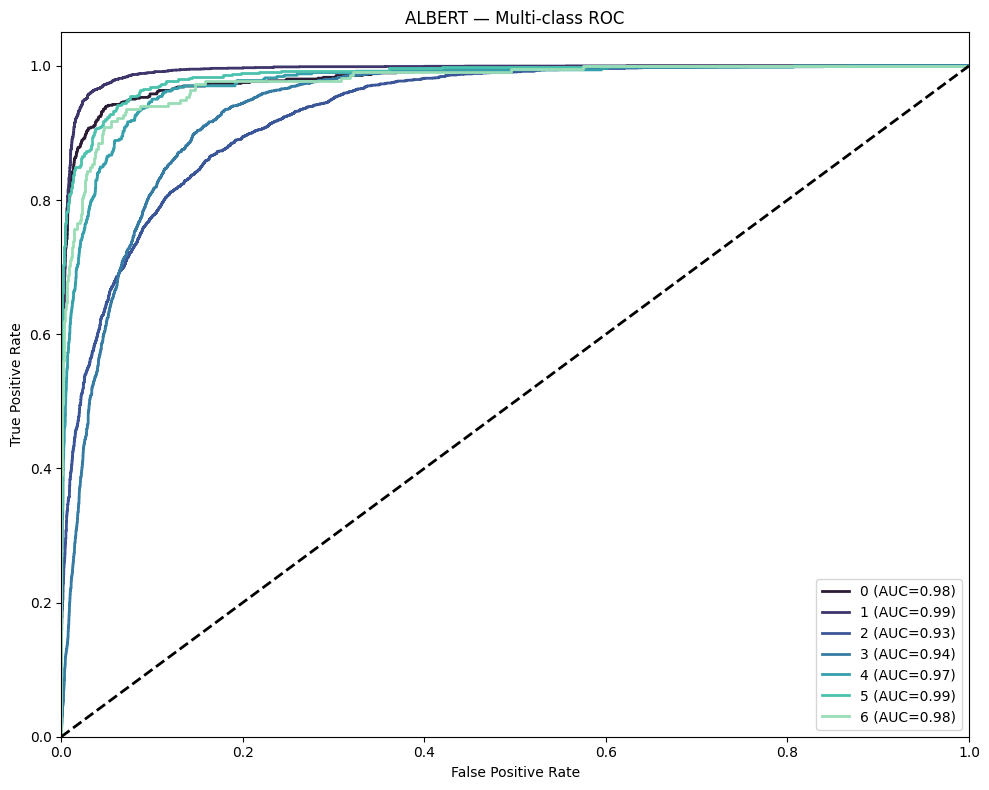

In [ ]:
albert_preds, albert_probs, y_true_albert = evaluate_pytorch(
    best_albert, test_loader_albert, label_encoder, "ALBERT", use_attention_mask=True
)

### 4.4.3 BioBERT Modeling

#### Step 1: Data Preparation

In [ ]:
print("\nPre-tokenizing for BioBERT...")
biobert_name = "dmis-lab/biobert-v1.1"
biobert_tokenizer = AutoTokenizer.from_pretrained(biobert_name)

train_ids_bio, train_masks_bio = batch_tokenize(train_texts_dl, biobert_tokenizer, MAX_TOKEN_LENGTH)
val_ids_bio, val_masks_bio     = batch_tokenize(val_texts_dl, biobert_tokenizer, MAX_TOKEN_LENGTH)
test_ids_bio, test_masks_bio   = batch_tokenize(test_texts_dl, biobert_tokenizer, MAX_TOKEN_LENGTH)
print(f"BioBERT tokens: train={train_ids_bio.shape}")

train_loader_biobert = DataLoader(
    TransformerDataset(train_ids_bio, train_masks_bio, train_labels_dl),
    shuffle=True, **_tf_loader_kw)
val_loader_biobert = DataLoader(
    TransformerDataset(val_ids_bio, val_masks_bio, val_labels_dl),
    shuffle=False, **_tf_loader_kw)
test_loader_biobert = DataLoader(
    TransformerDataset(test_ids_bio, test_masks_bio, test_labels_dl),
    shuffle=False, **_tf_loader_kw)


Pre-tokenizing for BioBERT...


config.json:   0%|          | 0.00/462 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

BioBERT tokens: train=torch.Size([31976, 200])


#### Step 2: Hyperparameter Tuning

In [ ]:
RETRAIN = True

if RETRAIN:
    set_seed()
    print("\nTuning BioBERT...")
    start = time.time()

    biobert_param_space = {
        "lr": (np.log10(1e-5), np.log10(3e-5)),
        "epochs": (4, 10),
        "dropout": (0.0, 0.25),
    }

    best_f1_biobert, best_params_biobert, best_biobert = 0, None, None

    for i in tqdm(range(N_ITERATIONS), desc="BioBERT Random Search"):
        hp = {
            "lr": float(10 ** np.random.uniform(*biobert_param_space["lr"])),
            "epochs": int(np.random.randint(*biobert_param_space["epochs"])),
            "dropout": float(np.random.uniform(*biobert_param_space["dropout"])),
        }

        model = AutoModelForSequenceClassification.from_pretrained(
            biobert_name, num_labels=NUM_CLASSES,
        )
        model.config.hidden_dropout_prob = hp["dropout"]
        model.config.attention_probs_dropout_prob = hp["dropout"]

        if TORCH_COMPILE_OK:
            model = torch.compile(model, mode="reduce-overhead")

        f1_val, model = train_transformer(
            model, train_loader_biobert, val_loader_biobert,
            lr=hp["lr"], max_epochs=hp["epochs"], patience=3,
        )

        if f1_val > best_f1_biobert:
            best_f1_biobert = f1_val
            best_params_biobert = hp
            best_biobert = model

        del model
        gc.collect()
        torch.cuda.empty_cache()

    print(f"BioBERT tuning: {time.time()-start:.1f}s | Best F1={best_f1_biobert:.4f}")
    print(f"Best params: {best_params_biobert}")

    torch.save(best_biobert.state_dict(), MODEL_PATHS["biobert"]["model"])
else:
    print("Loading BioBERT from disk...")
    best_biobert = AutoModelForSequenceClassification.from_pretrained(
        biobert_name, num_labels=NUM_CLASSES,
    )
    best_biobert.load_state_dict(torch.load(MODEL_PATHS["biobert"]["model"], map_location=DEVICE))
    print(f"Loaded BioBERT from {MODEL_PATHS['biobert']['model']}")



Tuning BioBERT...


BioBERT Random Search:   0%|          | 0/10 [00:00<?, ?it/s]

pytorch_model.bin:   0%|          | 0.00/433M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dmis-lab/biobert-v1.1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dmis-lab/biobert-v1.1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/9 | Loss=1.4351 | Val F1=0.6445
  Epoch 2/9 | Loss=0.6518 | Val F1=0.7627
  Epoch 3/9 | Loss=0.4613 | Val F1=0.7740
  Epoch 4/9 | Loss=0.3398 | Val F1=0.7943
  Epoch 5/9 | Loss=0.2610 | Val F1=0.7965
  Epoch 6/9 | Loss=0.2180 | Val F1=0.7928
  Epoch 7/9 | Loss=0.1865 | Val F1=0.8008
  Epoch 8/9 | Loss=0.1678 | Val F1=0.8015
  Epoch 9/9 | Loss=0.1611 | Val F1=0.8023


BioBERT Random Search: 100%|██████████| 10/10 [47:08<00:00, 282.82s/it]


BioBERT tuning: 2828.2s | Best F1=0.8023
Best params: {'lr': 2.9768448441450054e-05, 'epochs': 9, 'dropout': 0.2365358833708563}


#### Step 3: Model Evaluation

Eval BioBERT: 100%|██████████| 83/83 [00:03<00:00, 23.54it/s]



Evaluation: BioBERT
                      precision    recall  f1-score   support

             Anxiety     0.8187    0.8551    0.8365       766
              Normal     0.9422    0.9460    0.9441      3275
          Depression     0.8192    0.6801    0.7432      3092
            Suicidal     0.6676    0.8151    0.7340      2136
              Stress     0.6642    0.7222    0.6920       504
             Bipolar     0.8471    0.8229    0.8348       559
Personality disorder     0.7245    0.6514    0.6860       218

            accuracy                         0.8117     10550
           macro avg     0.7834    0.7847    0.7815     10550
        weighted avg     0.8188    0.8117    0.8117     10550

Weighted F1: 0.8114  95% CI [0.8039, 0.8190]
Saved → ./01_OriginalLabel/outputs/BioBERT_confusion_matrix.png


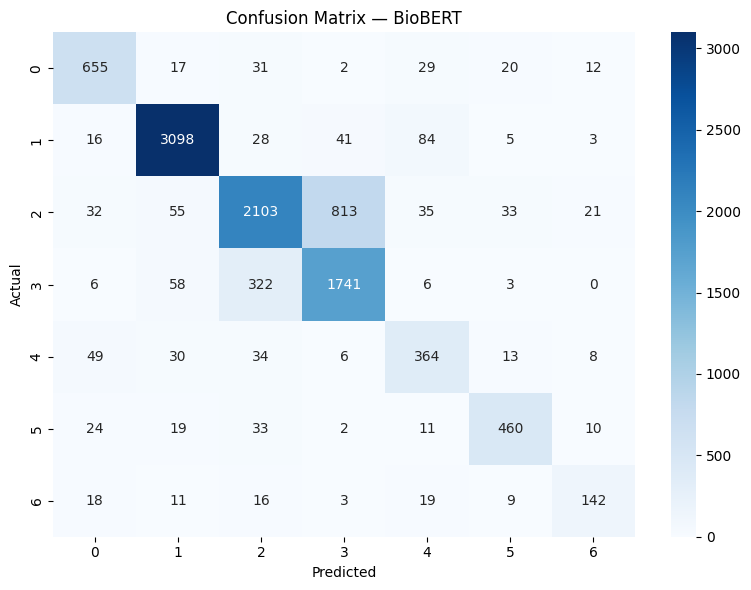

Macro AUC: 0.9656  95% CI [0.9625, 0.9687]
Saved → ./01_OriginalLabel/outputs/BioBERT_roc_curve.png


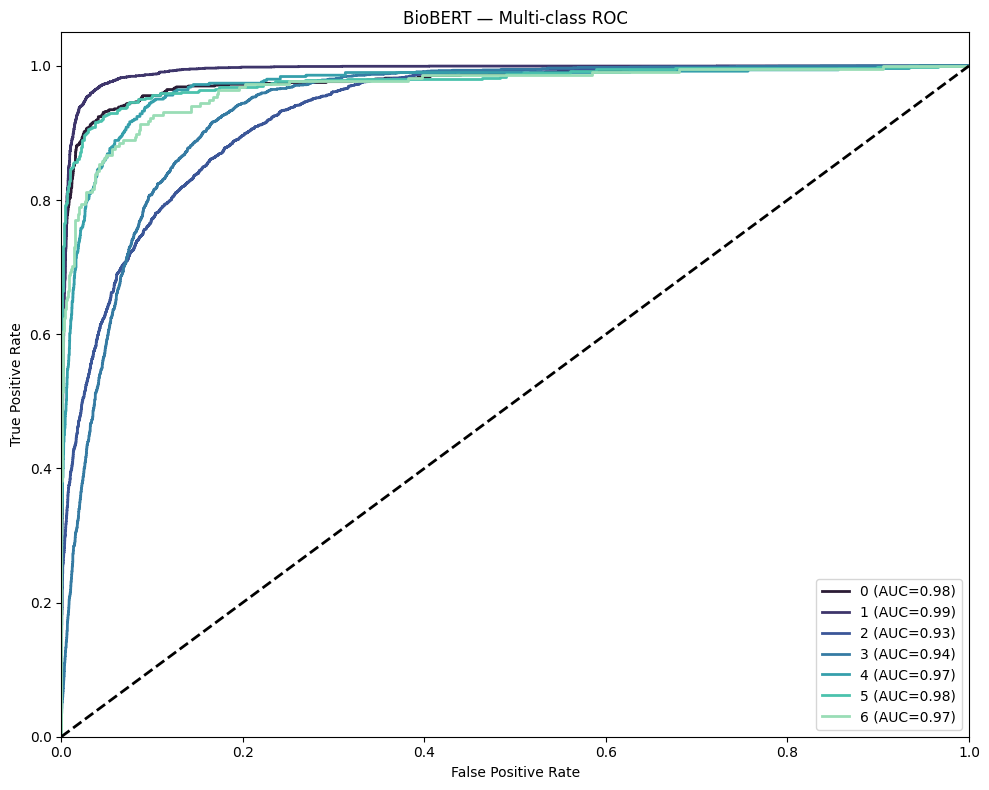

In [ ]:
biobert_preds, biobert_probs, y_true_biobert = evaluate_pytorch(
    best_biobert, test_loader_biobert, label_encoder, "BioBERT", use_attention_mask=True
)

## 4.3 Save Predictions for DL models

In [ ]:
print("\nSaving DL predictions...")

# Verify all DL models evaluated on same test set
assert np.array_equal(y_true_gru, y_true_cnn)
assert np.array_equal(y_true_gru, y_true_albert)
assert np.array_equal(y_true_gru, y_true_biobert)
y_true_dl = y_true_gru

true_names = label_encoder.inverse_transform(y_true_dl)

if "id" in df_test_dl.columns:
    df_pred_dl = df_test_dl[["id", TEXT_COLUMN, LABEL_COLUMN_ENCODED]].copy()
else:
    df_pred_dl = df_test_dl[[TEXT_COLUMN, LABEL_COLUMN_ENCODED]].copy()
    df_pred_dl.insert(0, "id", df_test_dl.index)

df_pred_dl = df_pred_dl.rename(columns={TEXT_COLUMN: "text", LABEL_COLUMN_ENCODED: "true_label_id"})
df_pred_dl["true_label"] = true_names

for name, preds, probs in [
    ("gru", gru_preds, gru_probs),
    ("cnn", cnn_preds, cnn_probs),
    ("albert", albert_preds, albert_probs),
    ("biobert", biobert_preds, biobert_probs),
]:
    df_pred_dl[f"{name}_pred_id"] = preds
    df_pred_dl[f"{name}_pred"] = label_encoder.inverse_transform(preds)
    for i, cls in enumerate(label_encoder.classes_):
        df_pred_dl[f"{name}_prob_{cls}"] = probs[:, i]

dl_pred_path = OUTPUT_PATH / "dl_models_predictions.csv"
df_pred_dl.to_csv(dl_pred_path, index=False)
print(f"Saved DL predictions → {dl_pred_path}")


Saving DL predictions...
Saved DL predictions → ./01_OriginalLabel/outputs/dl_models_predictions.csv


# 5. Model Comparison

In [13]:
print("\n" + "="*60)
print("MODEL COMPARISON — McNemar Pairwise Tests")
print("="*60)

# Load both prediction files
df_ml_pred = pd.read_csv(OUTPUT_PATH / "ml_models_predictions.csv")
df_dl_pred = pd.read_csv(OUTPUT_PATH / "dl_models_predictions.csv")

df_merged = pd.merge(df_ml_pred, df_dl_pred, on=["id", "true_label", "true_label_id"],
                     suffixes=("_ml", "_dl"))
print(f"Merged: {df_merged.shape[0]} rows")

y_true_all = df_merged["true_label_id"].values

# Build prediction dict
model_preds_all = {
    "LR":      label_encoder.transform(df_merged["lr_pred"].values),
    "SVM":     label_encoder.transform(df_merged["svm_pred"].values),  # <-- add this
    "RF":      label_encoder.transform(df_merged["rf_pred"].values),
    "LGBM":    label_encoder.transform(df_merged["lgbm_pred"].values),
    "GRU":     df_merged["gru_pred_id"].values,
    "CNN":     df_merged["cnn_pred_id"].values,
    "ALBERT":  df_merged["albert_pred_id"].values,
    "BioBERT": df_merged["biobert_pred_id"].values,
}

# Verify lengths
for name, arr in model_preds_all.items():
    assert len(arr) == len(y_true_all), f"{name} length mismatch"


def mcnemar_pairwise(y_true, model_preds, method="bonferroni"):
    y_true = np.asarray(y_true)
    names = list(model_preds.keys())
    results = []

    for m1, m2 in combinations(names, 2):
        y1, y2 = np.asarray(model_preds[m1]), np.asarray(model_preds[m2])
        c1 = (y1 == y_true)
        c2 = (y2 == y_true)

        a = np.sum(c1 & c2)
        b = np.sum(c1 & ~c2)
        c = np.sum(~c1 & c2)
        d = np.sum(~c1 & ~c2)

        res = mcnemar(np.array([[a, b], [c, d]]), exact=False, correction=True)
        p = res.pvalue

        if p >= 0.05:
            winner = "Inconclusive"
        elif b > c:
            winner = f"{m1} > {m2}"
        elif c > b:
            winner = f"{m2} > {m1}"
        else:
            winner = "Tie"

        results.append({
            "Model_1": m1, "Model_2": m2,
            "both_correct": a, "m1_only": b, "m2_only": c, "both_wrong": d,
            "statistic": res.statistic, "p_raw": p, "winner_raw": winner,
        })

    raw_p = [r["p_raw"] for r in results]
    _, corrected_p, _, _ = multipletests(raw_p, method=method)

    for i, pc in enumerate(corrected_p):
        results[i]["p_corrected"] = pc
        results[i]["significant"] = "Yes" if pc < 0.05 else "No"

    df_res = pd.DataFrame(results)
    print(f"\nPairwise McNemar Tests (corrected: {method}):")
    print(df_res.to_string(index=False))
    return df_res


df_mcnemar = mcnemar_pairwise(y_true_all, model_preds_all)

# Save
mcnemar_path = OUTPUT_PATH / "mcnemar_results.csv"
df_mcnemar.to_csv(mcnemar_path, index=False)
print(f"\nSaved McNemar results → {mcnemar_path}")

print("\n✓ Pipeline complete.")


MODEL COMPARISON — McNemar Pairwise Tests
Merged: 10550 rows

Pairwise McNemar Tests (corrected: bonferroni):
Model_1 Model_2  both_correct  m1_only  m2_only  both_wrong  statistic        p_raw     winner_raw  p_corrected significant
     LR     SVM          7714      294      319        2223   0.939641 3.323702e-01   Inconclusive 1.000000e+00          No
     LR      RF          7030      978      831        1711  11.783306 5.976426e-04        LR > RF 1.673399e-02         Yes
     LR    LGBM          7455      553      700        1842  17.011971 3.714488e-05      LGBM > LR 1.040057e-03         Yes
     LR     GRU          6924     1084     1063        1479   0.186306 6.660087e-01   Inconclusive 1.000000e+00          No
     LR     CNN          7197      811      959        1583  12.208475 4.757292e-04       CNN > LR 1.332042e-02         Yes
     LR  ALBERT          7311      697     1242        1300 152.623002 4.630906e-35    ALBERT > LR 1.296654e-33         Yes
     LR BioBERT      